# Imports

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from utils_EDA import (outlier_count_IQR, outlier_filter_IQR,
                            bar_charts_categorical, distribution_plot_grid,
                            cor_heatmap, chi2_TestIndependence)
pd.options.display.float_format = '{:.2f}'.format
pd.options.display.max_columns = None

In [3]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv')
data.head()
%cd EDA

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\EDA



ses e urbanicity - variavel com 4 em vez de 5 valores - considerar ? como missing

recenc_star_status - Keep as ordinal count (0, 1, 2, ...) after capping outliers em vez de any value > 0 means 'was a star', clamp to 0/1, a formaa como a variavel está distribuida faz sentido, por isso vamos considerar que a descrição está errada e que isto na verdade é o nmr de vezes que a pessoa fez o star status. a descrição da variavel está errada ou a variavel mudou e a descrição nao foi atualizada


em várias variaveis - valores com muitas casas decimais vamos considerar missing values because o mesmo valor com varias casas decimais aparece muitas vezes. ver ponto 3 do docs. compilando os dados, ha valores que são mal calculados ou que não fazem sentido. mas temos de ter em atenção para no recent_response_prop por exemplo, em variaveis de proporções, para não afetar os dados originais (podemos considerar missing com mais de 3 casas decimais).


questionar: recent car response prop e recent response porp ver ponto 3.4


a dos meses passar


age - limite a 18 e 100, e valores abaixo de 18 e acima de 100 consideramos missing


month_since_last_prom_resp - tirar o sinal considerar erro na introdução da variavel porque os numeros, embora negativos, fazem sentido

variaveiss com muitos missing values - weatlh rating, tem ordem, por isso é muito arriscado fazer imputation (metade da variavel iria ser inventada). dar drop e não utilizar. income_group tem 25% por isso vamos com imputation numérica, em vez de usar a moda, usar knn imputer


questionar - recency_status e doações quando inactive e lapsing  .....




# General Data Exploration

In [4]:
data['CONTROL_NUMBER'].duplicated().sum()

np.int64(0)

We can conclude that there are no repeated unique identifiers of each donor, this means we can and will use the CONTROL_NUMBER variable as the index for our Dataframe. We wil then check whether there are any duplicate entries in all of the other columns, in other words fully identical donors with different CONTROL_NUMBER.

In [5]:
data.set_index('CONTROL_NUMBER', inplace=True)

In [6]:
data.duplicated().sum()

np.int64(0)

From the above cell, we can be certain that all donor profiles are unique and not repeated. Now, we will start to look deeper at the actual data, with regards to column-specific issues and insights. 

| Attribute | Description | Variable Type |
| :--- | :--- | :--- |
| **CONTROL_NUMBER** | Unique identifier of each possible donor | ID (Drop/Index) |
| **DONOR_AGE** | Age as of last year's mail solicitation | Numerical |
| **URBANICITY** | Nature of the donor's location U = Urban C = City T = Town R = Rural S=Suburban | Categorical |
| **SES** | Code assigning each individual to one of 5 demographic profiles based on socioeconomic characteristics | Categorical (Ordinal) |
| **HOME_OWNER** | H if individual is a Homeowner, U if it is Unknown | Categorical |
| **DONOR_GENDER** | Gender of individual | Categorical |
| **INCOME_GROUP** | Code assigning each individual to one of 7 income group levels | Categorical (Ordinal) |
| **WEALTH_RATING** | Code assigning each individual to one of 10 wealth rating groups | Categorical (Ordinal) |
| **MEDIAN_HOME_VALUE** | Individuals' median home value in $100's | Numerical |
| **MEDIAN_HOUSEHOLD_INCOME** | Individuals' median household income in $100's | Numerical |
| **PCT_OWNER_OCCUPIED** | Percent of owner-occupied housing near where person lives | Numerical |
| **PER_CAPITA_INCOME** | Per Capita Income of neighborhood in which person lives | Numerical |
| **PCT_ATTRIBUTE1** | Percent of residents in person's neighborhood that are male and active military | Numerical |
| **PCT_ATTRIBUTE2** | Percent of residents in person's neighborhood that are male and veterans | Numerical |
| **PCT_ATTRIBUTE3** | Percent of residents in person's neighborhood that are Vietnam veterans | Numerical |
| **PCT_ATTRIBUTE4** | Percent of residents in person's neighborhood that are WW2 veterans | Numerical |
| **PEP_STAR** | If person achieved STAR donor status, given to individuals who have given to 3 consecutive campaigns. | Binary |
| **RECENT_STAR_STATUS** | If achieved STAR within last 4 years. | Binary |
| **RECENCY_STATUS_96NK** | Donor status: A (active - made their first donation more than 12 months ago and has made a donation in the last 12 months.); E (inactive - made a donation 25+ months ago.); F (first time - made their first donation in the last 6 months and has made just one donation.); L (lapsing - made their last donation between 13-24 months ago); N (new - made their first donation in the last 12 months and is not a First time donor); S (star donor) | Categorical |
| **FREQUENCY_STATUS_97NK** | Number of times donated in last period (The period of recency for all groups except L and E is the last 12 months. For L it is 13-24 months ago, and for E it is 25-36 months ago). | Numerical |
| **RECENT_RESPONSE_PROP** | Proportion of responses to the individual to the number of (card or other) solicitations from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_GIFT_AMT** | Average donation from the individual to the charitable organization in the last four years. | Numerical |
| **RECENT_CARD_RESPONSE_PROP** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_AVG_CARD_GIFT_AMT** | Average donation from the individual in response to a card solicitation from the charitable organization in the last four years | Numerical |
| **RECENT_RESPONSE_COUNT** | Number of times the individual has responded to a promotion (card or other) from the charitable organization in the last four years | Numerical |
| **RECENT_CARD_RESPONSE_COUNT** | Number of times the individual has responded to a card solicitation from the charitable organization in the last four years. | Numerical |
| **MONTHS_SINCE_LAST_PROM_RESP** | Number of months since the individual has responded to a promotion by the charitable organization | Numerical |
| **LIFETIME_CARD_PROM** | Total number of card promotions sent to the individual by the charitable organization | Numerical |
| **LIFETIME_PROM** | Total number of promotions (card or other) sent to the individual by the charitable organization | Numerical |
| **LIFETIME_GIFT_AMOUNT** | Total lifetime donation amount from the individual to the charitable organization | Numerical |
| **LIFETIME_GIFT_COUNT** | Total number of donations from the individual to the charitable organization | Numerical |
| **LIFETIME_MAX_GIFT_AMT** | Maximum donation amount from individual | Numerical |
| **LIFETIME_MIN_GIFT_AMT** | Minimum donation amount from individual | Numerical |
| **LAST_GIFT_AMT** | Amount donated in the individuals most recent donation | Numerical |
| **CARD_PROM_12** | Number of card promotions sent to the individual by the charitable organization in the last 12 months | Numerical |
| **NUMBER_PROM_12** | Number of promotions (card or other) sent to the individual by the charitable organization in the last 12 months | Numerical |
| **MONTHS_SINCE_LAST_GIFT** | Number of months since the most recent donation from the individual to the charitable organization | Numerical |
| **MONTHS_SINCE_FIRST_GIFT** | Number of months since the first donation from the individual to the charitable organization | Numerical |
| **FILE_CARD_GIFT** | Lifetime average donation from the individual in response to all card solicitations from the charitable organization | Numerical |
| **CHILDREN** | Number of children the individual has | Numerical |
| **TARGET_B** | Whether person has donated in the last year's campaign or not (1 or 0 respectively) | Binary / Target |

In [7]:
data.info()

<class 'pandas.DataFrame'>
Index: 13560 entries, 61745 to 45722
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CARD_PROM_12                 13297 non-null  float64
 1   CHILDREN                     13298 non-null  float64
 2   DONOR_AGE                    10006 non-null  float64
 3   DONOR_GENDER                 13288 non-null  str    
 4   FILE_CARD_GIFT               13300 non-null  float64
 5   FREQUENCY_STATUS_97NK        13278 non-null  float64
 6   HOME_OWNER                   13274 non-null  str    
 7   INCOME_GROUP                 10271 non-null  float64
 8   LAST_GIFT_AMT                13299 non-null  float64
 9   LIFETIME_CARD_PROM           13300 non-null  float64
 10  LIFETIME_GIFT_AMOUNT         13287 non-null  float64
 11  LIFETIME_GIFT_COUNT          13285 non-null  float64
 12  LIFETIME_MAX_GIFT_AMT        13300 non-null  float64
 13  LIFETIME_MIN_GIFT_AMT       

In [8]:
data.columns

Index(['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'DONOR_GENDER',
       'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'HOME_OWNER', 'INCOME_GROUP',
       'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT',
       'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT',
       'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME',
       'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT',
       'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1',
       'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4',
       'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENCY_STATUS_96NK', 'RECENT_AVG_CARD_GIFT_AMT',
       'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT',
       'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT',
       'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES', 'URBANICITY',
       'WEALTH_RATING', 'TARGET_B'],
      dtype='str')

In [7]:
cat_cols = list(data.select_dtypes(include='str').columns) + ['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'PEP_STAR']
cat_cols

['DONOR_GENDER',
 'HOME_OWNER',
 'RECENCY_STATUS_96NK',
 'SES',
 'URBANICITY',
 'INCOME_GROUP',
 'RECENT_STAR_STATUS',
 'WEALTH_RATING',
 'PEP_STAR']

In [8]:
data.describe(include=['object'])

C:\Users\dinis\AppData\Local\Temp\ipykernel_32084\1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,DONOR_GENDER,HOME_OWNER,RECENCY_STATUS_96NK,SES,URBANICITY
count,13288,13274,13298,13287,13291
unique,3,2,6,5,6
top,F,H,A,2,S
freq,7230,7233,8188,6380,3117


In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CARD_PROM_12,13297.00,5.38,1.32,1.00,5.00,6.00,6.00,17.00
CHILDREN,13298.00,2.00,1.47,-2.30,1.00,2.00,3.00,6.22
DONOR_AGE,10006.00,58.81,17.57,0.00,46.00,60.00,73.00,108.95
FILE_CARD_GIFT,13300.00,5.24,4.83,-10.10,2.00,4.00,8.00,32.00
FREQUENCY_STATUS_97NK,13278.00,1.99,1.15,-1.36,1.00,2.00,3.00,5.28
INCOME_GROUP,10271.00,3.92,1.96,-1.74,2.00,4.00,5.00,9.50
LAST_GIFT_AMT,13299.00,16.64,12.95,-21.83,10.00,15.00,20.00,450.00
LIFETIME_CARD_PROM,13300.00,18.65,8.94,-7.21,11.00,18.00,26.00,55.00
LIFETIME_GIFT_AMOUNT,13287.00,104.88,112.12,-243.26,41.00,80.00,133.00,3775.00
LIFETIME_GIFT_COUNT,13285.00,9.99,9.10,-18.63,4.00,8.00,14.00,95.00


In [10]:
data[(data['DONOR_AGE'] % 1 != 0) & (~data['DONOR_AGE'].isna())]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3319,7.00,0.00,8.66,F,5.00,2.00,U,5.00,10.00,25.00,136.00,10.00,20.00,10.00,83.00,2808.00,552.00,93.00,15.00,20.00,31.00,0.00,27.00,36.00,32.00,89.00,NaN,21502.00,A,0.00,19.00,0.00,0.00,2.00,0.10,0.00,1,S,7.00,0
62629,6.00,0.00,8.66,M,6.00,NaN,U,5.00,10.00,28.00,110.00,12.00,14.00,5.00,66.00,NaN,220.00,113.00,19.00,19.00,13.00,0.00,34.00,42.00,15.00,67.00,0.00,12261.00,A,9.50,9.75,2.00,0.20,4.00,0.21,0.00,2,T,3.00,0
13133,6.00,2.00,108.95,F,8.00,2.00,H,4.00,26.00,22.00,213.00,15.00,26.00,5.00,91.00,3222.00,677.00,77.00,20.00,20.00,35.00,0.00,50.00,34.00,28.00,94.00,1.00,34728.00,S,23.50,23.50,2.00,0.22,2.00,0.10,1.00,1,S,3.00,0
147614,6.00,3.00,108.95,U,2.00,2.00,U,NaN,20.00,11.00,46.00,3.00,20.00,10.00,23.00,4155.00,454.00,30.00,18.00,18.00,13.00,0.00,0.00,0.00,0.00,57.00,0.00,28357.00,A,13.00,15.33,2.00,0.29,3.00,0.23,0.00,4,U,NaN,0
183924,4.00,0.00,108.95,M,1.00,1.00,H,4.00,15.00,11.00,20.00,2.00,15.00,5.00,28.00,462.00,252.00,40.00,26.00,26.00,9.00,0.00,35.00,15.00,43.00,79.00,0.00,13610.00,A,0.00,15.00,0.00,0.00,1.00,0.06,0.00,2,C,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87397,6.00,4.00,108.95,F,9.00,1.00,H,4.00,11.00,25.00,120.30,11.00,18.00,7.30,59.00,718.00,206.00,104.00,22.00,22.00,12.00,0.00,34.00,36.00,21.00,88.00,-0.53,11129.00,S,11.00,12.75,3.00,0.30,4.00,0.19,1.00,2,R,9.00,0
99273,NaN,0.00,8.66,M,1.00,2.00,H,7.00,20.00,14.00,65.00,5.00,20.00,10.00,33.00,2941.00,654.00,NaN,17.00,17.00,8.00,0.00,30.00,54.00,10.00,70.00,0.00,33387.00,A,20.00,13.33,1.00,0.09,3.00,0.14,0.00,1,NaN,NaN,0
138110,6.00,NaN,8.66,F,13.00,3.00,U,2.00,14.00,34.00,296.00,27.00,16.00,5.00,84.00,863.00,357.00,129.00,18.00,18.00,14.00,0.00,53.00,25.00,59.00,88.00,1.00,18247.00,S,13.00,12.40,2.00,0.20,5.00,0.24,1.00,1,C,7.00,0


In [11]:
data[data['CHILDREN'] < 0]['CHILDREN'].value_counts()

CHILDREN
-2.30    67
Name: count, dtype: int64

In [12]:
data[data['FILE_CARD_GIFT'] < 0]['FILE_CARD_GIFT'].value_counts()

FILE_CARD_GIFT
-10.10    75
Name: count, dtype: int64

In [13]:
data[data['FREQUENCY_STATUS_97NK'] < 0]['FREQUENCY_STATUS_97NK'].value_counts()

FREQUENCY_STATUS_97NK
-1.36    66
Name: count, dtype: int64

In [14]:
data[data['INCOME_GROUP'] < 0]['INCOME_GROUP'].value_counts()

INCOME_GROUP
-1.74    68
Name: count, dtype: int64

In [15]:
data[data['INCOME_GROUP'] > 7]['INCOME_GROUP'].value_counts()

INCOME_GROUP
9.50    68
Name: count, dtype: int64

In [16]:
data[data['LAST_GIFT_AMT'] < 0]['LAST_GIFT_AMT'].value_counts()

LAST_GIFT_AMT
-21.83    67
Name: count, dtype: int64

In [17]:
data[~data['RECENT_STAR_STATUS'].isin([0,1])]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
80221,5.00,0.00,51.00,M,12.00,1.00,U,2.00,11.00,24.00,129.00,18.00,11.00,3.00,67.00,470.00,308.00,85.00,17.00,17.00,12.00,0.00,20.00,43.00,NaN,87.00,1.00,10616.00,A,9.67,9.67,3.00,0.33,3.00,0.17,6.00,2,NaN,4.00,0
144020,4.00,1.00,57.00,M,3.00,1.00,H,4.00,15.00,13.00,31.00,3.00,15.00,5.00,37.00,1727.00,200.00,52.00,21.00,21.00,10.00,0.00,4.00,0.00,24.00,28.00,0.00,6278.00,A,15.00,15.00,1.00,0.17,1.00,0.06,NaN,4,U,0.00,0
27419,4.00,-2.30,NaN,M,2.00,1.00,U,5.00,20.00,9.00,30.00,2.00,20.00,10.00,22.00,442.00,218.00,29.00,23.00,23.00,10.00,0.00,28.00,36.00,31.00,NaN,0.00,9399.00,A,15.00,15.00,2.00,0.33,2.00,0.15,-7.81,3,R,NaN,1
185248,5.00,0.00,NaN,F,13.00,1.00,H,6.00,15.00,28.00,237.00,26.00,15.00,3.00,86.00,788.00,364.00,113.00,5.00,18.00,21.00,5.00,21.00,0.00,23.00,98.00,1.00,11584.00,A,11.00,11.33,1.00,0.11,3.00,NaN,10.00,3,U,6.00,0
87417,5.00,2.00,47.00,F,NaN,1.00,U,2.00,25.00,23.00,343.00,20.00,25.00,5.00,64.00,619.00,236.00,75.00,27.00,NaN,11.00,0.00,30.00,16.00,28.00,70.00,1.00,12041.00,A,20.00,21.25,2.00,0.18,4.00,0.18,3.00,NaN,R,2.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136175,6.00,3.00,48.00,M,9.00,1.00,U,NaN,50.00,27.00,278.00,18.00,50.00,3.00,69.00,583.00,147.00,92.00,NaN,19.00,13.00,0.00,43.00,39.00,27.00,NaN,1.00,8530.00,A,22.50,28.75,2.00,0.18,4.00,0.18,8.00,3,T,-3.75,0
98973,6.00,2.00,73.00,F,8.00,1.00,U,1.00,15.00,32.00,147.00,15.00,16.00,3.00,72.00,315.00,223.00,130.00,25.00,25.00,11.00,1.00,34.00,26.00,38.00,80.00,1.00,10429.00,A,0.00,15.00,0.00,0.00,1.00,NaN,21.00,3,R,1.00,0
82252,4.00,2.00,66.00,M,10.00,1.00,H,7.00,14.00,27.00,111.00,13.00,14.00,5.00,65.00,1189.00,535.00,128.00,19.00,19.00,11.00,0.00,38.00,34.00,15.00,95.00,1.00,17285.00,A,NaN,13.00,1.00,0.14,2.00,0.11,11.00,1,T,8.00,0


In [18]:
num_cols = data.select_dtypes(include=np.number).columns.drop(['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'PEP_STAR', 'TARGET_B'])

In [19]:
((data[num_cols] < 0) | (data[num_cols] % 1 != 0)).sum()

CARD_PROM_12                     401
CHILDREN                         395
DONOR_AGE                       3690
FILE_CARD_GIFT                   402
FREQUENCY_STATUS_97NK            420
LAST_GIFT_AMT                    415
LIFETIME_CARD_PROM               410
LIFETIME_GIFT_AMOUNT             663
LIFETIME_GIFT_COUNT              391
LIFETIME_MAX_GIFT_AMT            412
LIFETIME_MIN_GIFT_AMT            545
LIFETIME_PROM                    393
MEDIAN_HOME_VALUE                396
MEDIAN_HOUSEHOLD_INCOME          407
MONTHS_SINCE_FIRST_GIFT          404
MONTHS_SINCE_LAST_GIFT           397
MONTHS_SINCE_LAST_PROM_RESP      573
NUMBER_PROM_12                   398
PCT_ATTRIBUTE1                   408
PCT_ATTRIBUTE2                   407
PCT_ATTRIBUTE3                   419
PCT_ATTRIBUTE4                   396
PCT_OWNER_OCCUPIED               392
PER_CAPITA_INCOME                403
RECENT_AVG_CARD_GIFT_AMT        3644
RECENT_AVG_GIFT_AMT             6213
RECENT_CARD_RESPONSE_COUNT       393
R

Alguns problemas (FALTAM OUTROS, VER TUDO):
+ All variables have missing values
+ DONOR_GENDER has NaN and U category
+ HOME_OWNER has missing values
+ RECENCY_STATUS_96NK has missing values
+ URBANICITY and SES have a "?" value
+ SES mentions 5 profiles in description but appears to only have 4 options in the data.
+ CHILDREN contains negative and non-integer values. All negative values are the same (-2.29)
+ DONOR_AGE has a minimum value of 0, values for underage people and non-integer values.
+ FILE_CARD_GIFT has negative values, which are all the same (-16.09857)
+ FREQUENCY_STATUS_97NK has negative values, which are all the same (-1.363824) and non-integer values.
+ INCOME_GROUP has negative values (-1.737977), non-integer values and values greater than 7 (9.563281)
+ LAST_GIFT_AMT has negative values (-21.8336)
+ PEP_STAR is an indicator of whether a donor has achieved STAR status, given to individuals who give to 3 consecutive campaigns, as such it should be binary variable, but it has various values outside of 0 and 1.
+ RECENT_STAR_STATUS is an indicator of whether a donor has achieved STAR status within the last 4 years, as such it should be binary variable, but it has various values outside of 0 and 1.

<Axes: xlabel='TARGET_B', ylabel='count'>

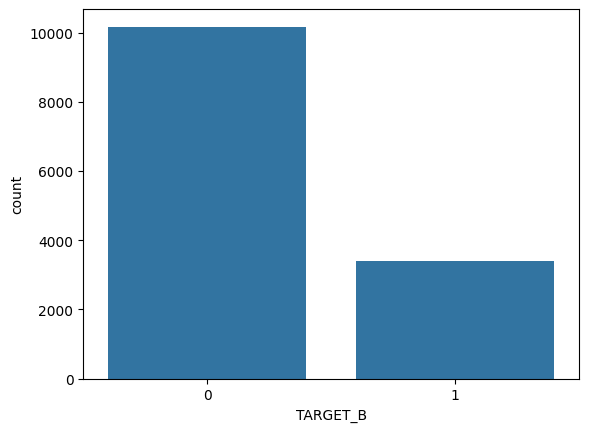

In [20]:
sns.countplot(data=data, x='TARGET_B')

# Missing Values

In [21]:
pd.merge(data.isna().sum().to_frame('N Missing'), data.isna().sum().to_frame('% Missing') / len(data) * 100, left_index=True, right_index=True)

,N Missing,% Missing
CARD_PROM_12,263,1.94
CHILDREN,262,1.93
DONOR_AGE,3554,26.21
DONOR_GENDER,272,2.01
FILE_CARD_GIFT,260,1.92
FREQUENCY_STATUS_97NK,282,2.08
HOME_OWNER,286,2.11
INCOME_GROUP,3289,24.26
LAST_GIFT_AMT,261,1.92
LIFETIME_CARD_PROM,260,1.92


In [22]:
data.isna().sum(axis=1).value_counts()

1    4324
2    3592
0    2345
3    2136
4     840
5     265
6      52
7       5
8       1
Name: count, dtype: int64

In [23]:
data[data.isna().sum(axis=1) >= 5]

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
63257,6.00,0.00,NaN,M,3.00,2.00,U,NaN,11.00,12.00,40.00,4.00,15.00,4.00,25.00,347.00,219.00,NaN,17.00,7.55,12.00,0.00,42.00,20.00,24.00,80.00,1.00,12850.00,A,NaN,12.00,3.00,0.38,3.00,0.23,0.00,3,C,NaN,0
50072,6.00,3.00,NaN,F,6.00,4.00,U,NaN,5.00,18.00,NaN,11.00,7.00,5.00,48.00,329.00,185.00,NaN,17.00,17.00,14.00,0.00,28.00,34.00,36.00,88.00,1.00,9344.00,A,5.50,5.50,4.00,NaN,4.00,0.21,0.00,3,R,NaN,0
112167,4.00,NaN,NaN,F,0.00,1.00,U,NaN,20.00,5.00,20.00,1.00,20.00,20.00,12.00,317.00,145.00,18.00,18.00,18.00,10.00,0.00,36.00,23.00,51.00,88.00,0.00,NaN,NaN,0.00,20.00,0.00,0.00,1.00,0.20,0.00,3,R,NaN,0
53212,NaN,3.00,NaN,F,2.00,1.00,U,NaN,16.00,NaN,26.00,2.00,16.00,10.00,23.00,814.00,-190.66,29.00,23.00,23.00,11.00,3.00,24.00,30.00,30.00,24.00,0.00,15419.00,A,13.00,13.00,2.00,0.33,2.00,0.15,0.00,2,R,NaN,0
130493,6.00,4.00,NaN,F,9.00,1.00,U,NaN,30.00,27.00,533.00,19.00,50.00,6.00,72.00,849.00,285.00,80.00,20.00,NaN,NaN,0.00,34.00,38.00,19.00,49.00,1.00,14907.00,A,40.00,40.00,2.00,0.18,NaN,0.10,15.00,1,S,6.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48966,6.00,4.00,NaN,M,1.00,1.00,H,5.00,31.00,13.00,83.00,3.00,31.00,25.00,30.00,866.00,385.00,32.00,17.00,17.00,13.00,0.00,42.00,8.00,NaN,86.00,0.00,20684.00,A,25.00,27.67,1.00,0.11,3.00,0.16,0.00,NaN,NaN,NaN,0
2311,11.00,0.00,NaN,M,6.00,4.00,U,NaN,7.00,27.00,80.00,15.00,10.00,NaN,66.00,817.00,488.00,62.00,7.00,15.00,26.00,0.00,0.00,0.00,0.00,95.00,0.00,18712.00,A,6.67,6.00,3.00,NaN,7.00,0.33,0.00,?,?,NaN,1
28759,5.00,3.00,NaN,M,10.00,1.00,U,NaN,10.00,32.00,132.00,21.00,10.00,3.00,74.00,0.00,0.00,126.00,25.00,28.00,11.00,0.00,NaN,44.00,20.00,0.00,1.00,0.00,A,NaN,5.50,-3.70,0.30,4.00,0.23,3.00,1,R,NaN,0


In [24]:
var_value_counts = data[data['URBANICITY'].isna()]['TARGET_B'].value_counts(normalize=True)
print(var_value_counts[0] > 0.8)

False


In [25]:
for var in data.columns[1:-1]:
    var_value_counts = data[data[var].isna()]['TARGET_B'].value_counts(normalize=True)
    if var_value_counts[0] < 0.8:
        print(var)
        display(var_value_counts)

CHILDREN


TARGET_B
0   0.74
1   0.26
Name: proportion, dtype: float64

DONOR_AGE


TARGET_B
0   0.76
1   0.24
Name: proportion, dtype: float64

DONOR_GENDER


...

TARGET_B
0   0.72
1   0.28
Name: proportion, dtype: float64

URBANICITY


TARGET_B
0   0.78
1   0.22
Name: proportion, dtype: float64

WEALTH_RATING


TARGET_B
0   0.76
1   0.24
Name: proportion, dtype: float64

# Outliers

In [26]:
num_cols = data.select_dtypes(include=np.number).columns.drop(['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING', 'TARGET_B'])

In [27]:
outlier_count_IQR(data, num_cols)

,N Outliers
CARD_PROM_12,1261
CHILDREN,133
DONOR_AGE,6
FILE_CARD_GIFT,437
FREQUENCY_STATUS_97NK,0
LAST_GIFT_AMT,553
LIFETIME_CARD_PROM,6
LIFETIME_GIFT_AMOUNT,803
LIFETIME_GIFT_COUNT,588
LIFETIME_MAX_GIFT_AMT,874


In [28]:
outlier_count_IQR(data, num_cols, outlier_type='extreme')

,N Outliers
CARD_PROM_12,265
CHILDREN,0
DONOR_AGE,0
FILE_CARD_GIFT,12
FREQUENCY_STATUS_97NK,0
LAST_GIFT_AMT,234
LIFETIME_CARD_PROM,0
LIFETIME_GIFT_AMOUNT,377
LIFETIME_GIFT_COUNT,89
LIFETIME_MAX_GIFT_AMT,561


In [29]:
outlier_filter_IQR(data, num_cols)

Excluding all normal outliers, we are left with 12.57% of our dataset


In [30]:
outlier_filter_IQR(data, num_cols, outlier_type='extreme')

Excluding all extreme outliers, we are left with 23.21% of our dataset


In [31]:
data[num_cols].quantile(0.95)

CARD_PROM_12                      6.00
CHILDREN                          4.00
DONOR_AGE                        83.00
FILE_CARD_GIFT                   15.00
FREQUENCY_STATUS_97NK             4.00
LAST_GIFT_AMT                    30.00
LIFETIME_CARD_PROM               32.00
LIFETIME_GIFT_AMOUNT            284.70
LIFETIME_GIFT_COUNT              28.00
LIFETIME_MAX_GIFT_AMT            36.00
LIFETIME_MIN_GIFT_AMT            23.00
LIFETIME_PROM                    84.00
MEDIAN_HOME_VALUE              3290.05
MEDIAN_HOUSEHOLD_INCOME         642.00
MONTHS_SINCE_FIRST_GIFT         128.00
MONTHS_SINCE_LAST_GIFT           26.00
MONTHS_SINCE_LAST_PROM_RESP      26.00
NUMBER_PROM_12                   24.00
PCT_ATTRIBUTE1                    5.00
PCT_ATTRIBUTE2                   49.00
PCT_ATTRIBUTE3                   55.65
PCT_ATTRIBUTE4                   65.00
PCT_OWNER_OCCUPIED               95.00
PEP_STAR                          1.00
PER_CAPITA_INCOME             31722.00
RECENT_AVG_CARD_GIFT_AMT 

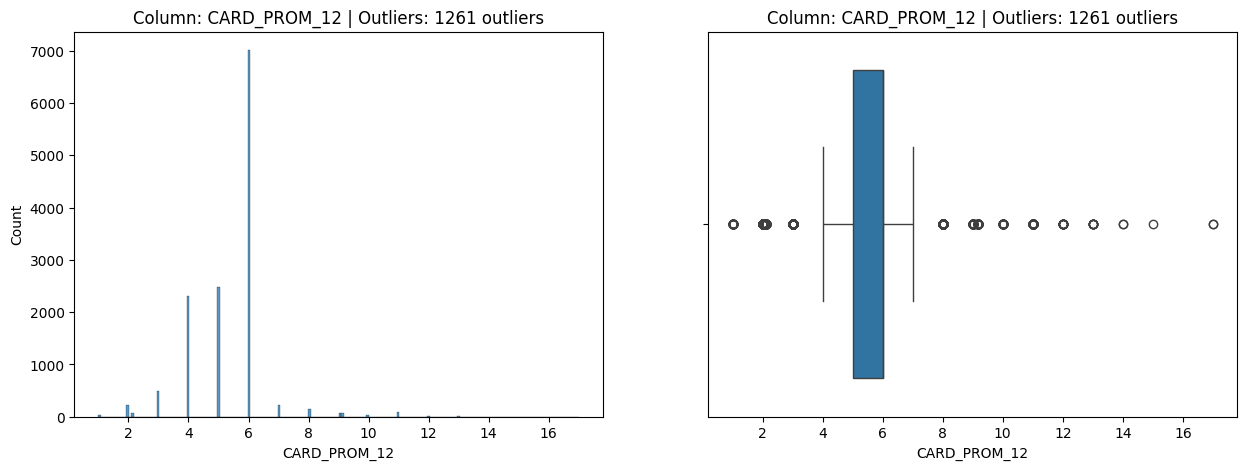

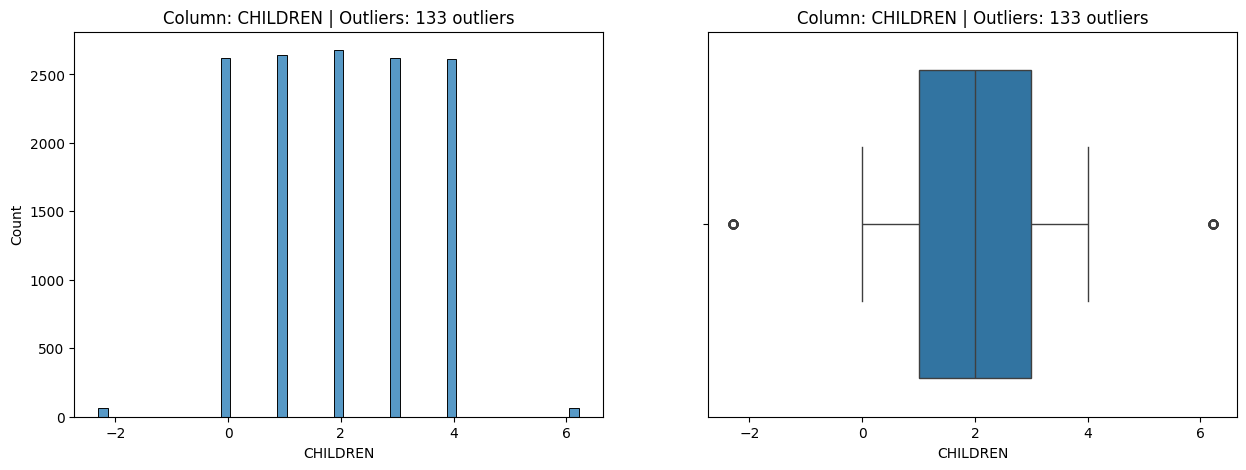

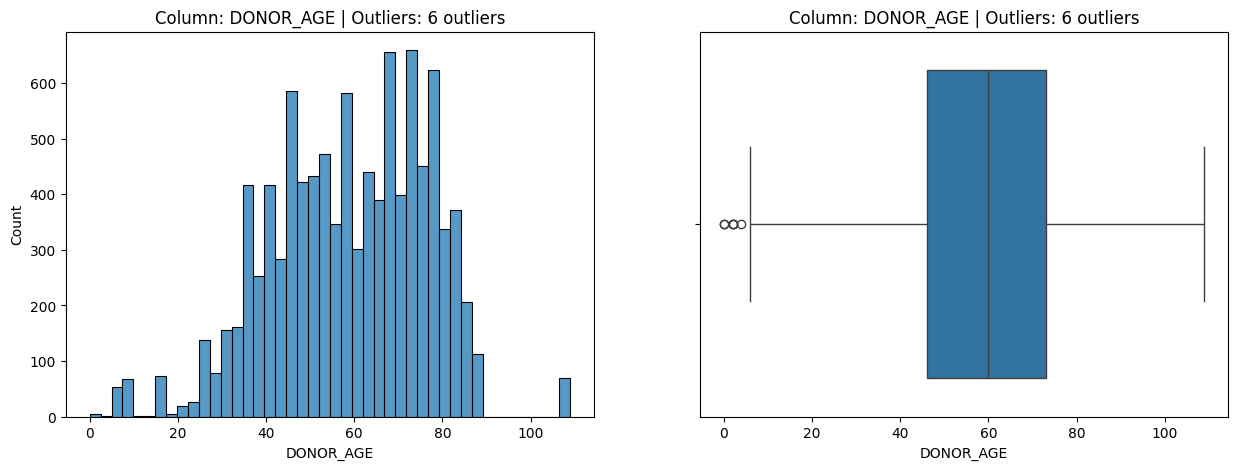

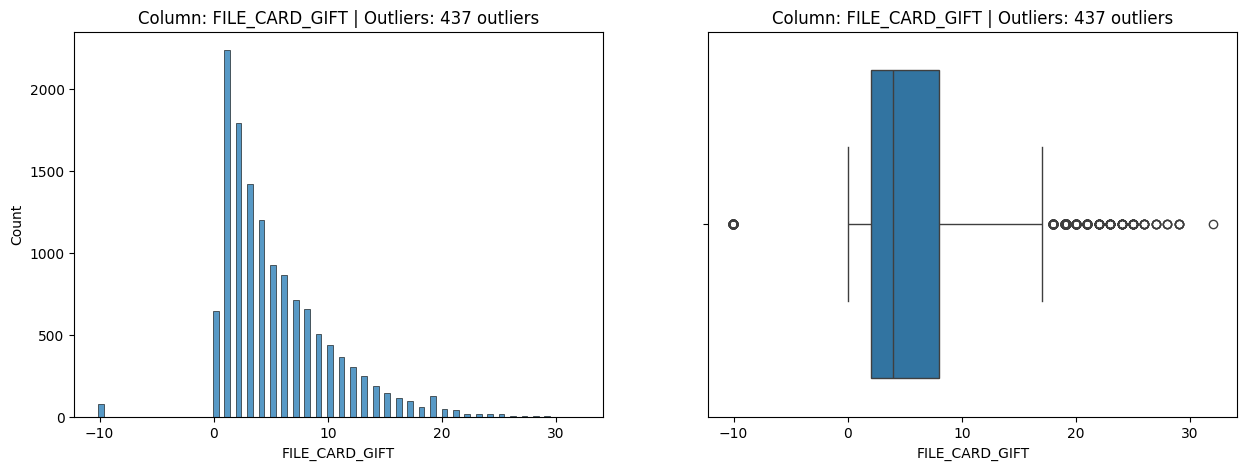

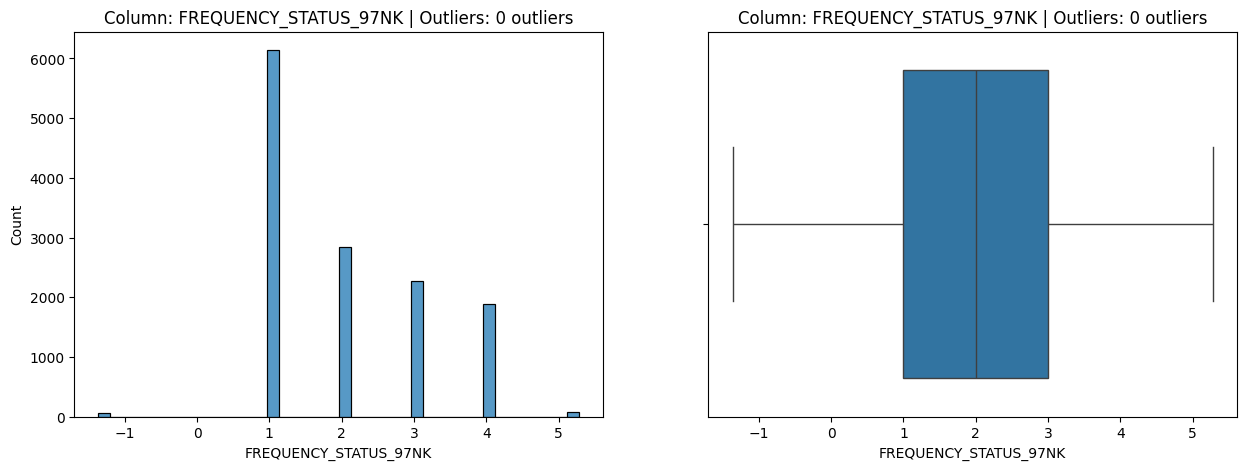

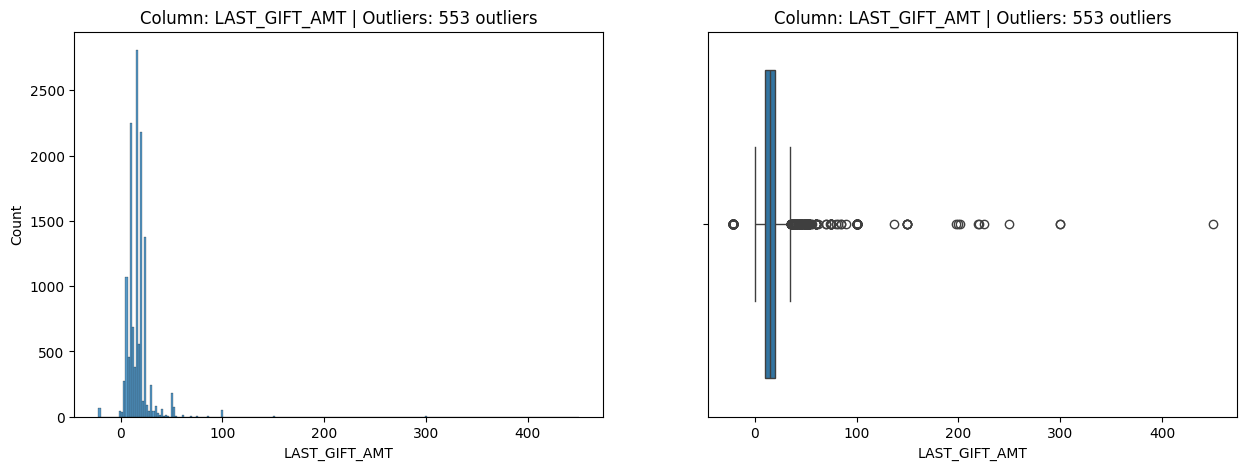

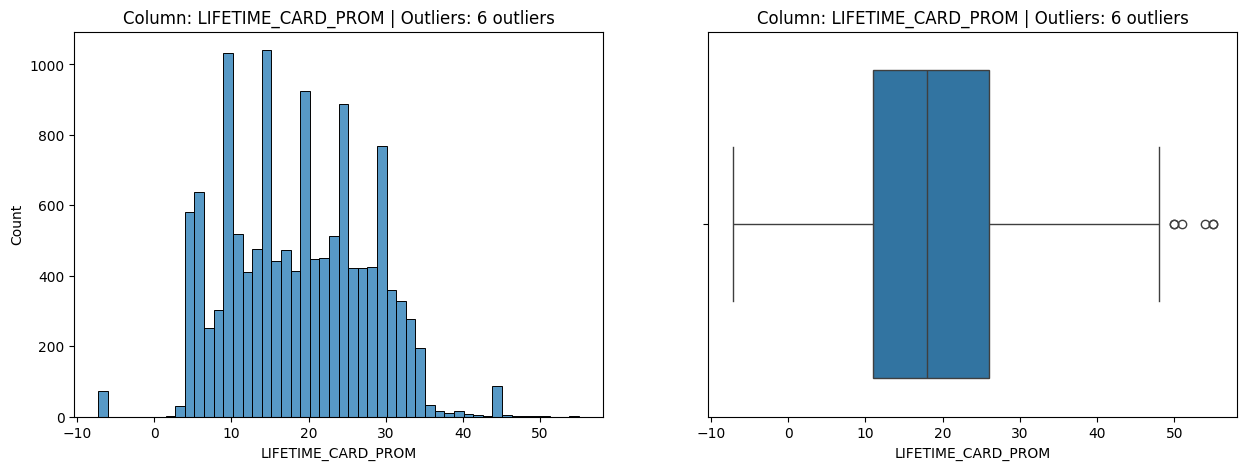

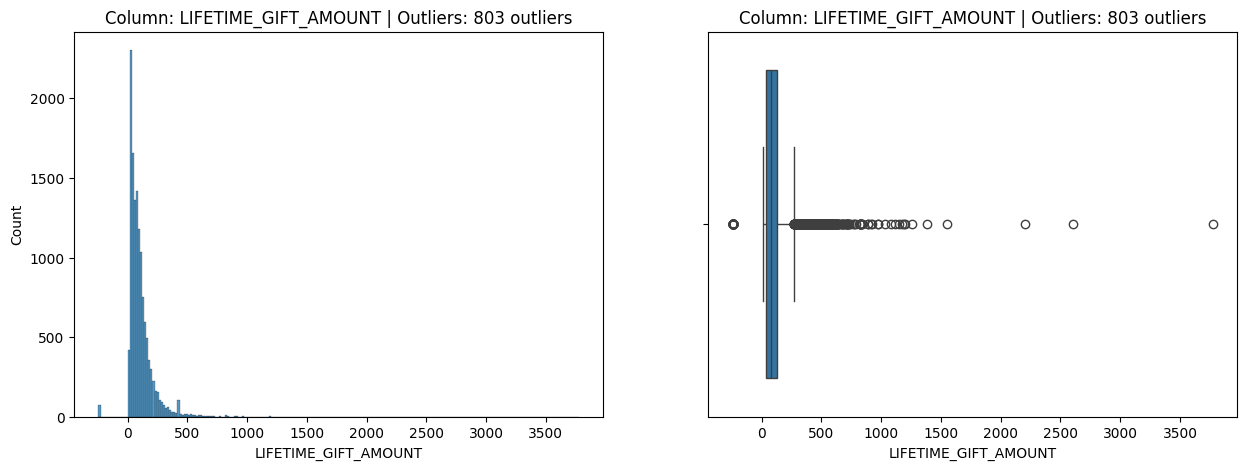

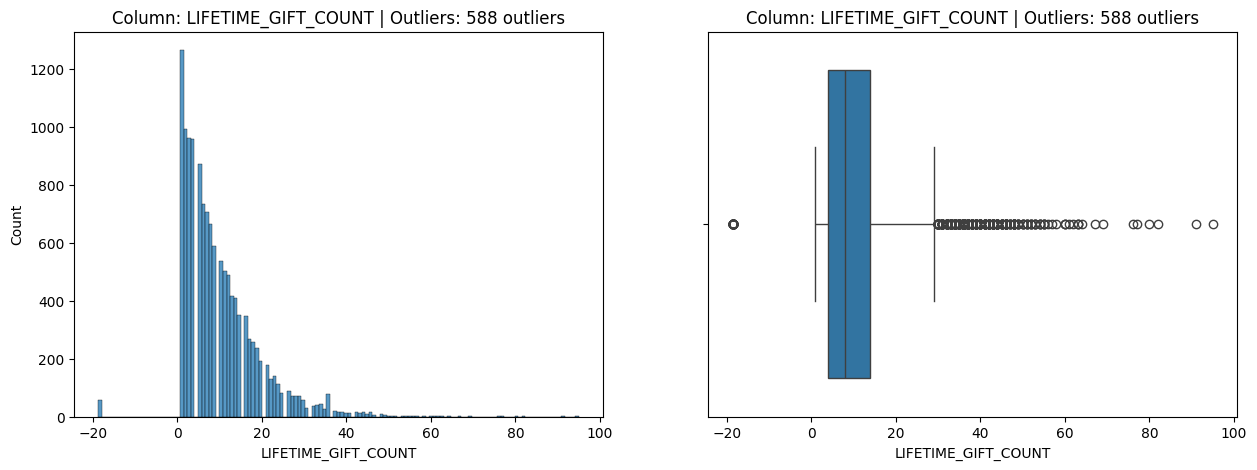

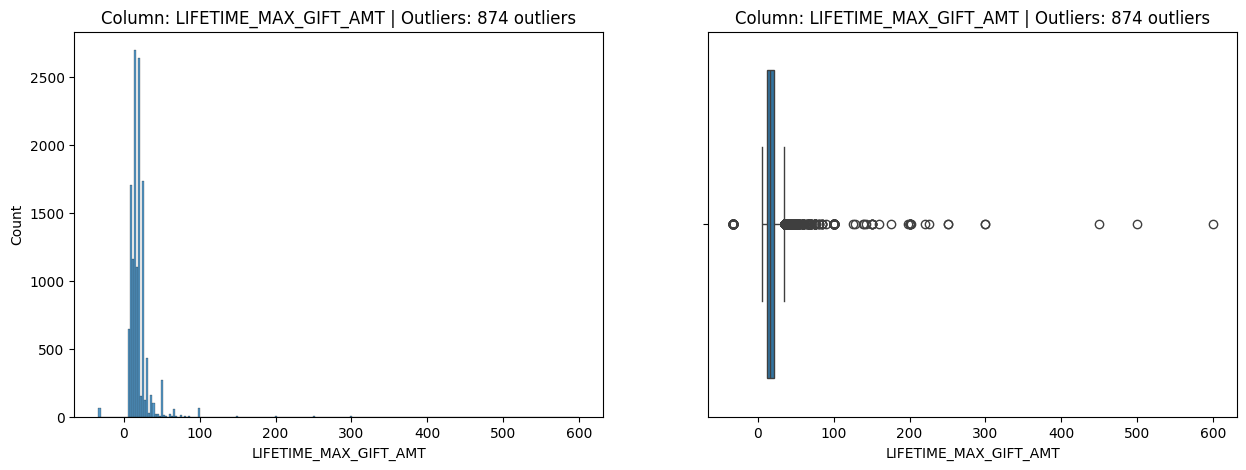

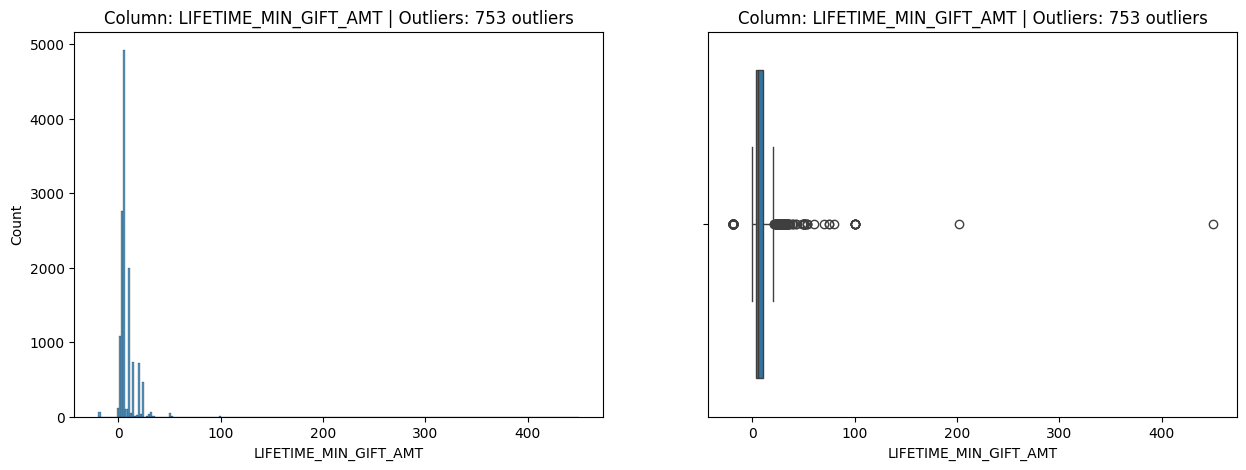

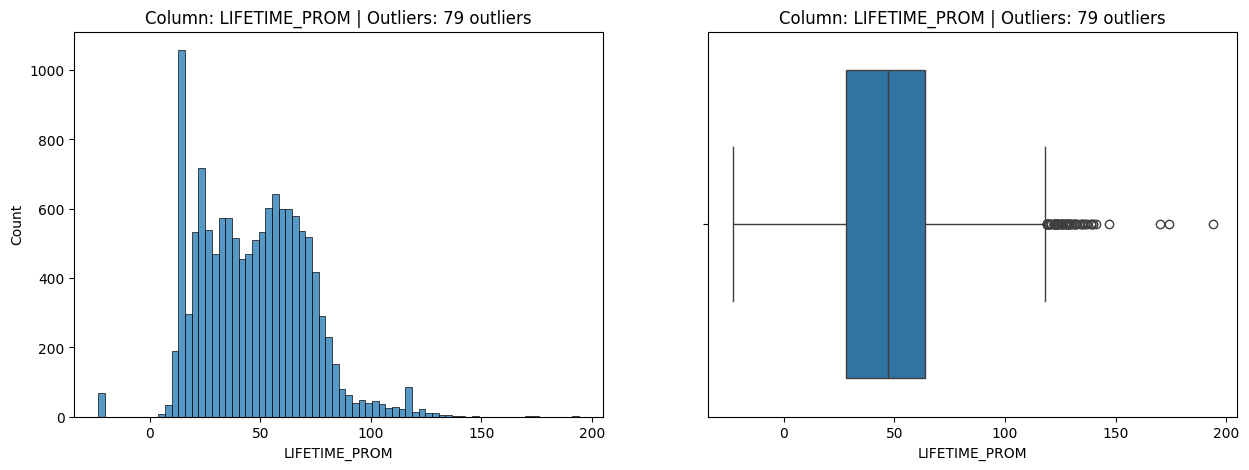

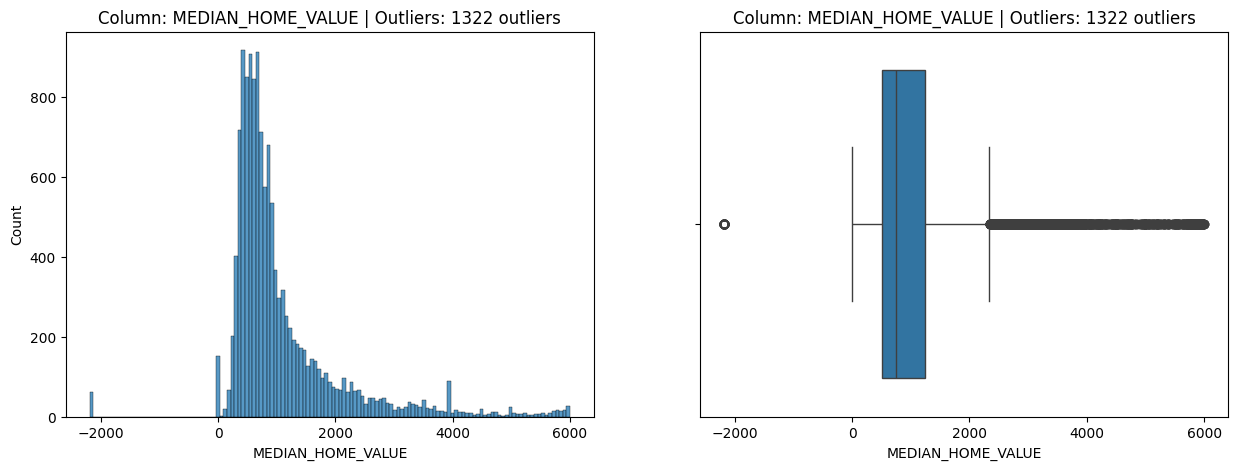

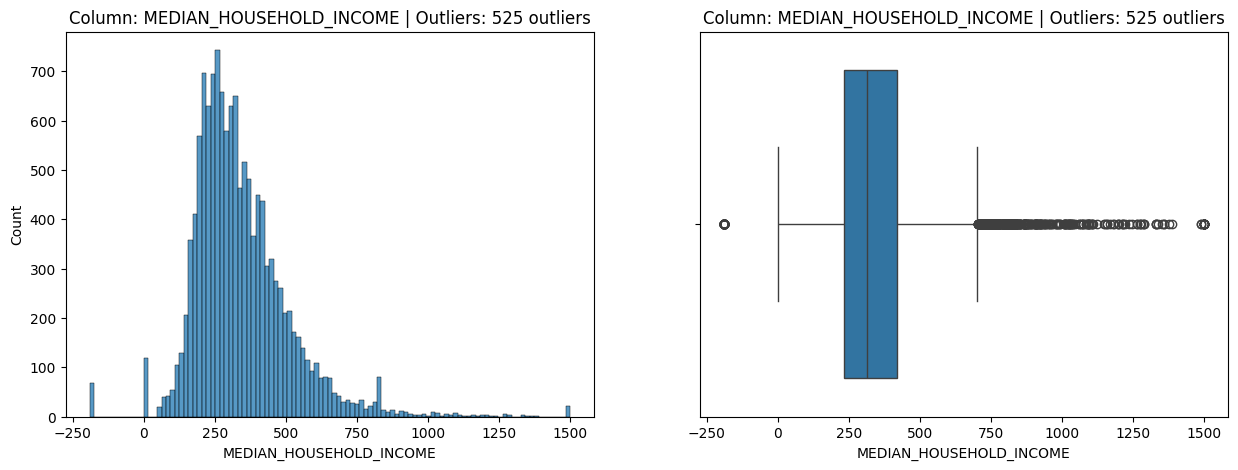

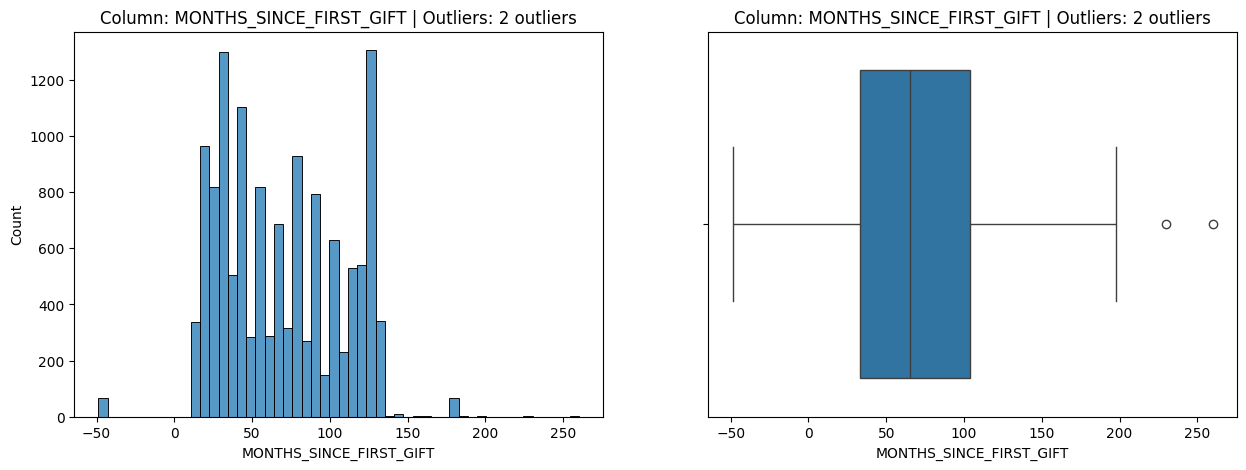

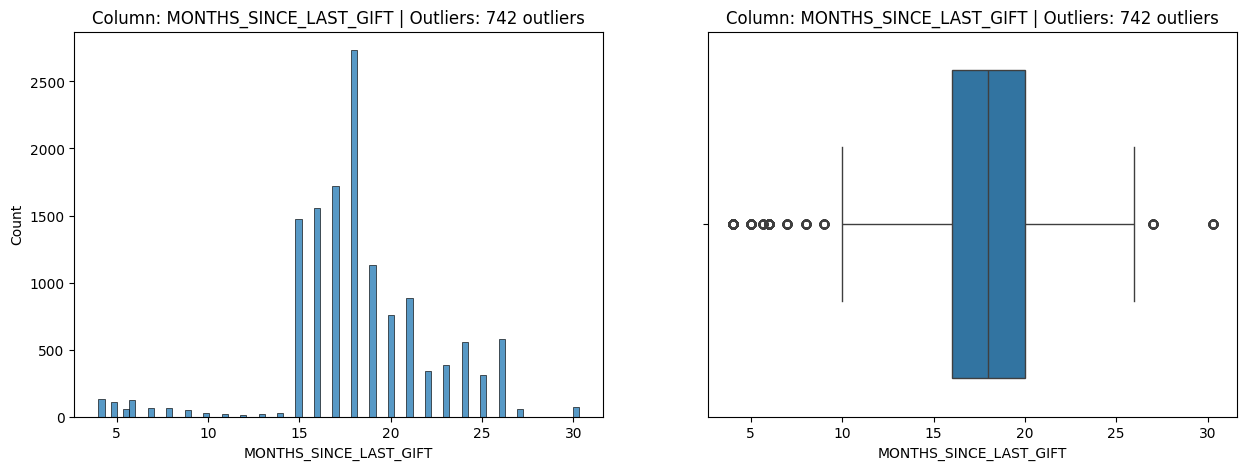

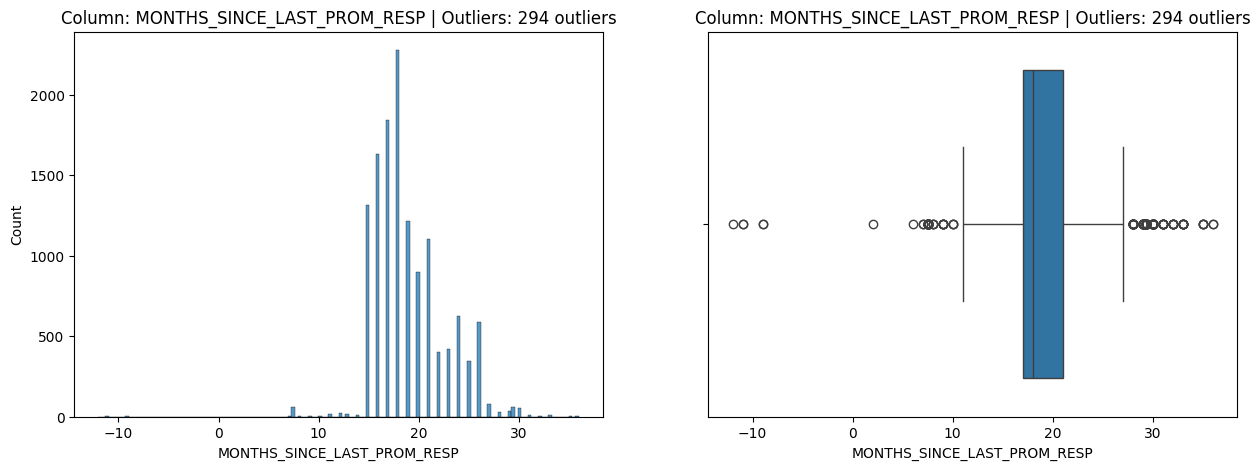

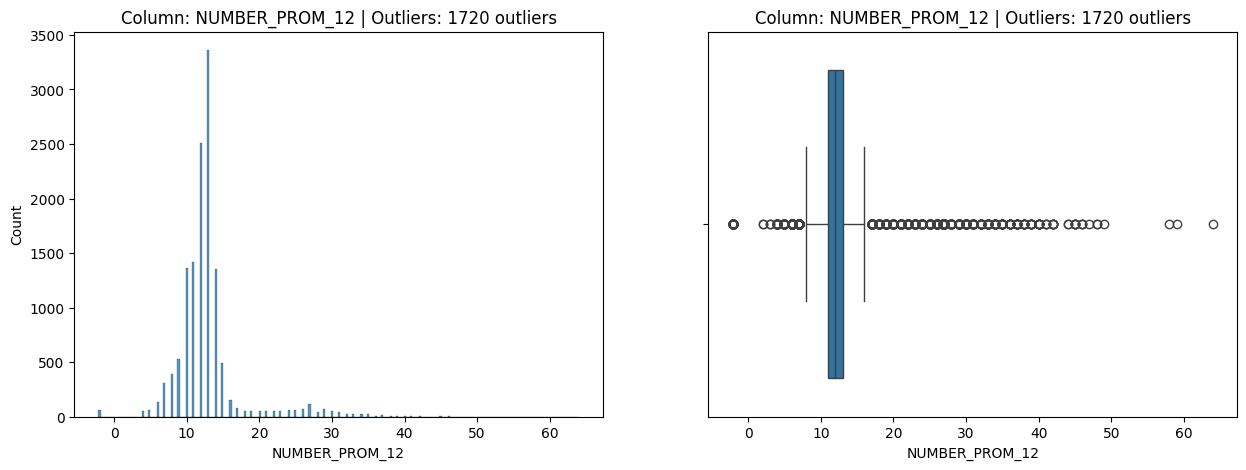

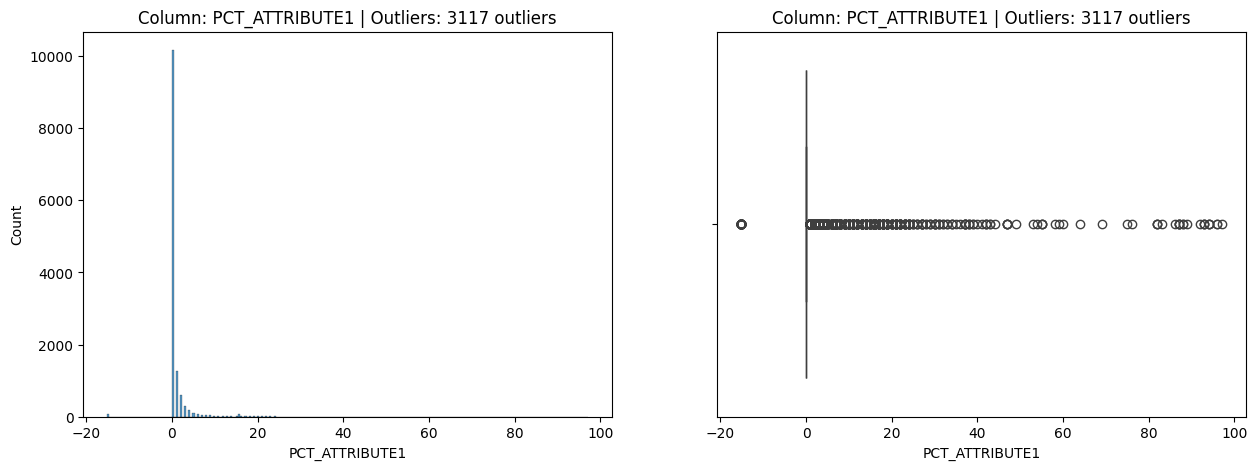

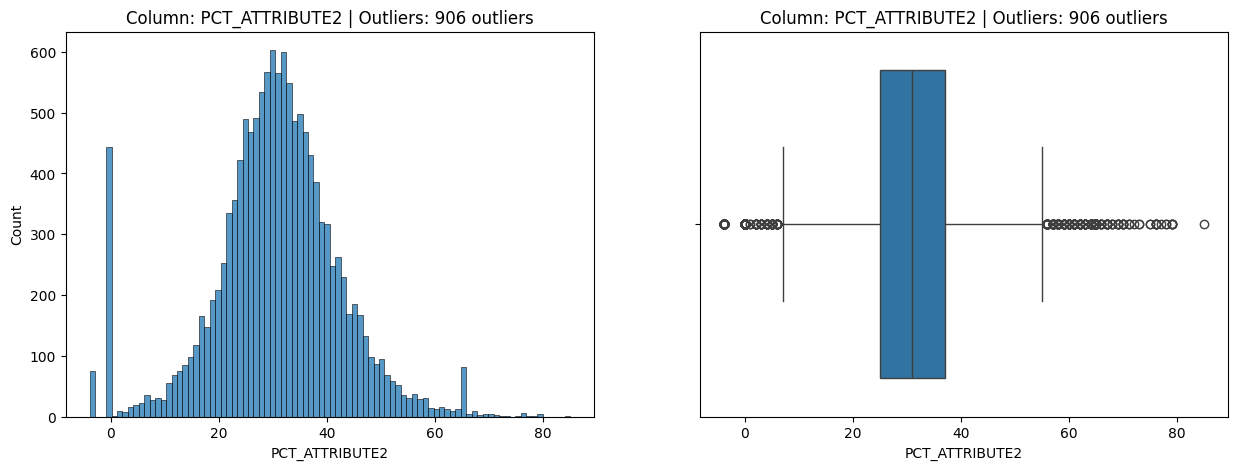

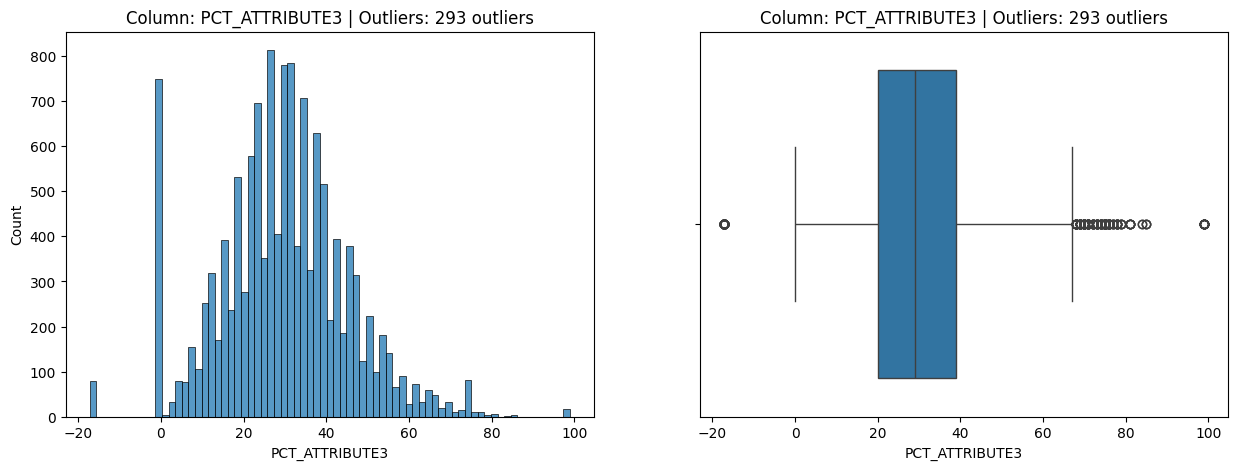

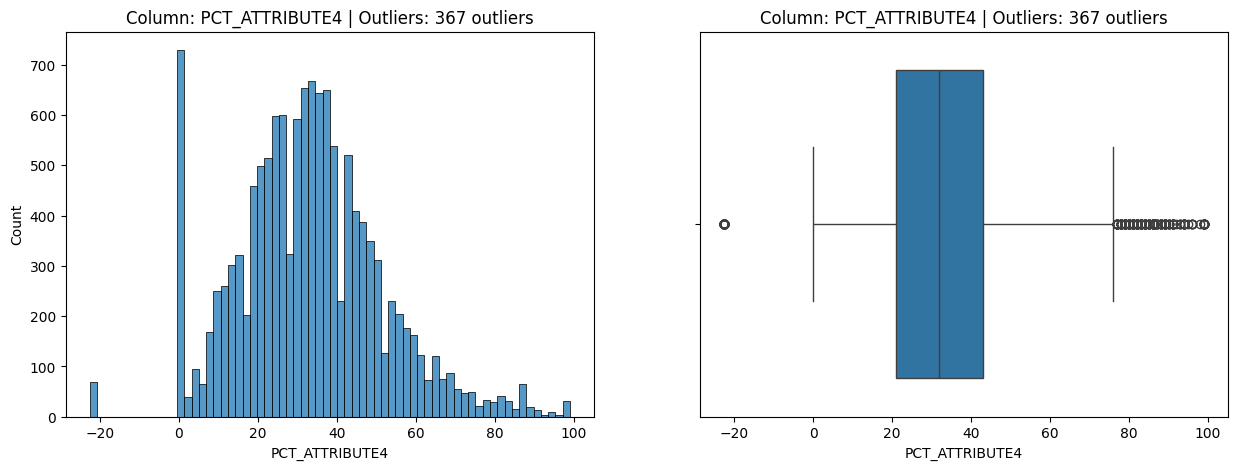

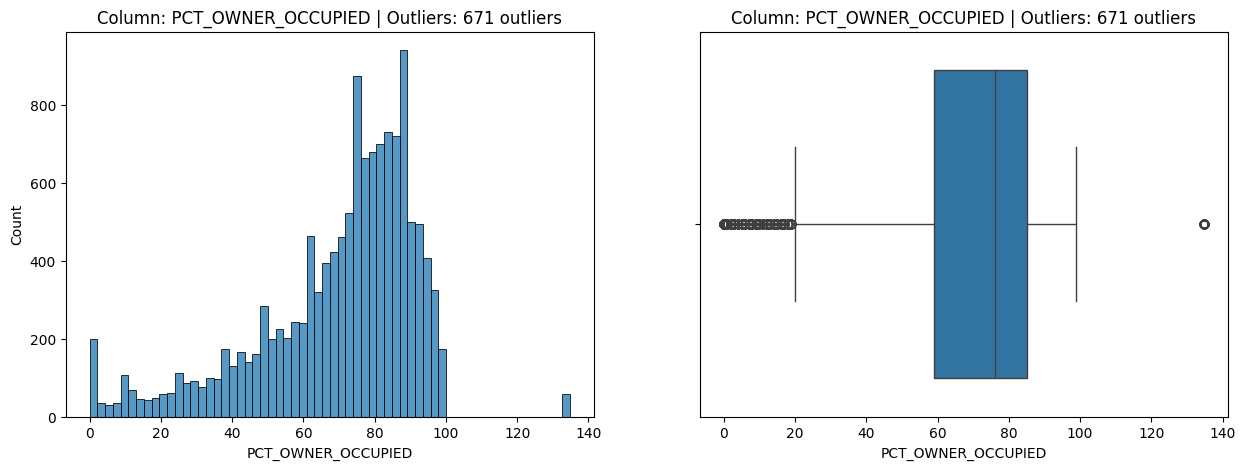

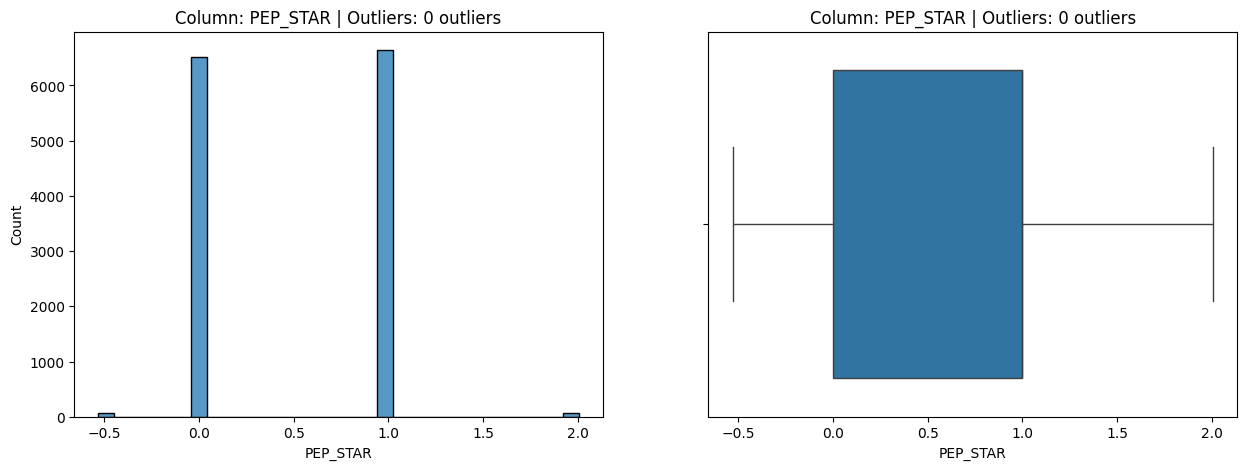

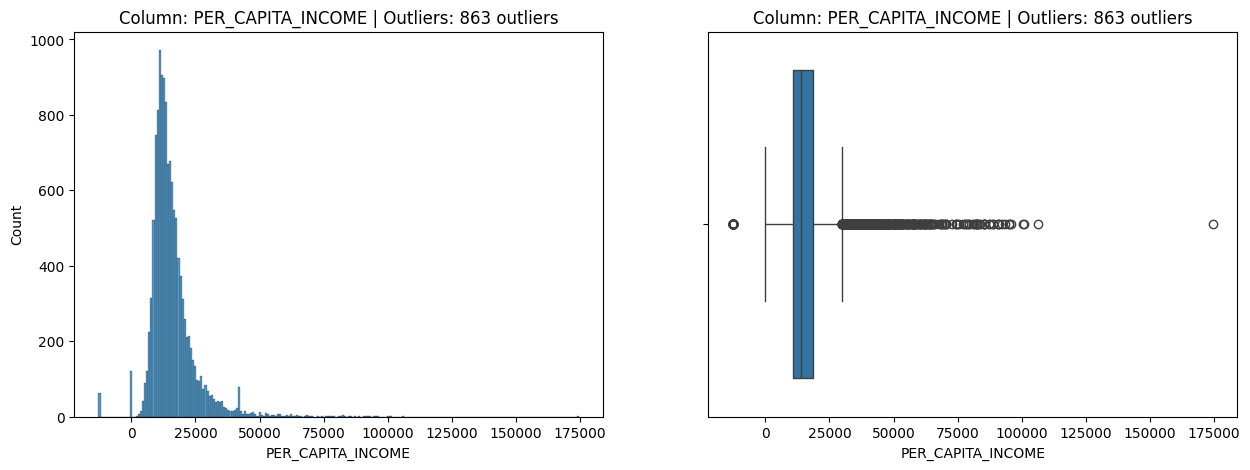

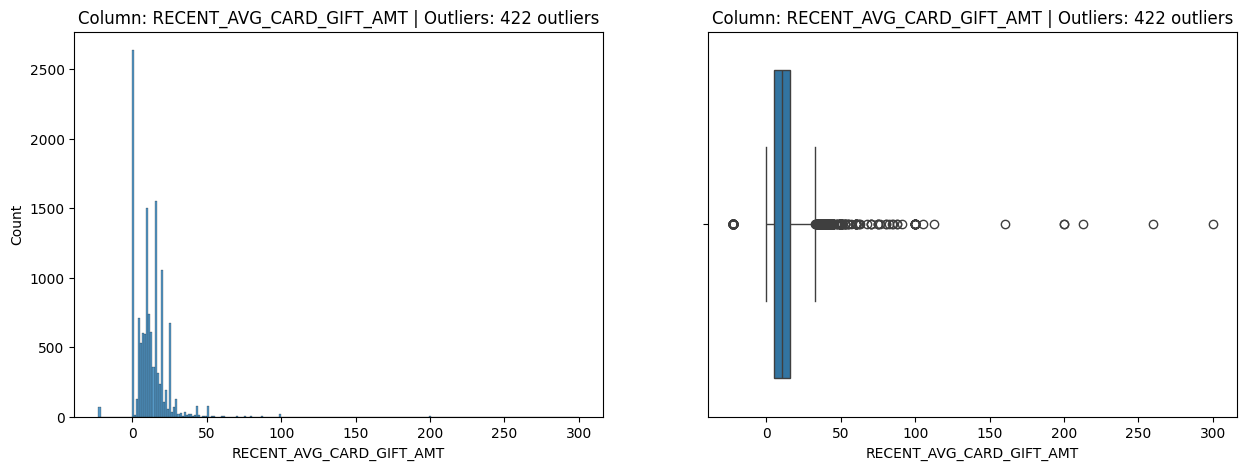

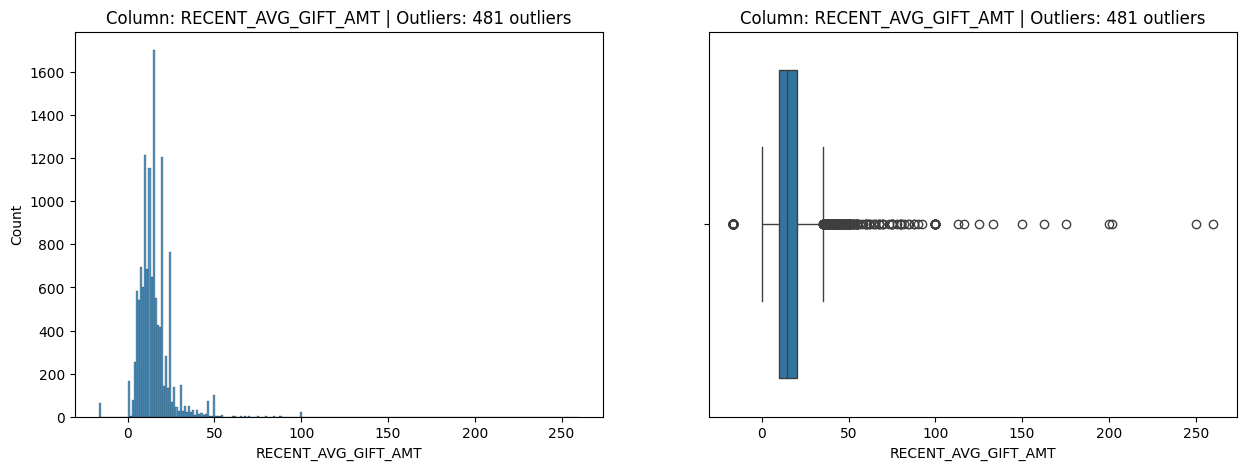

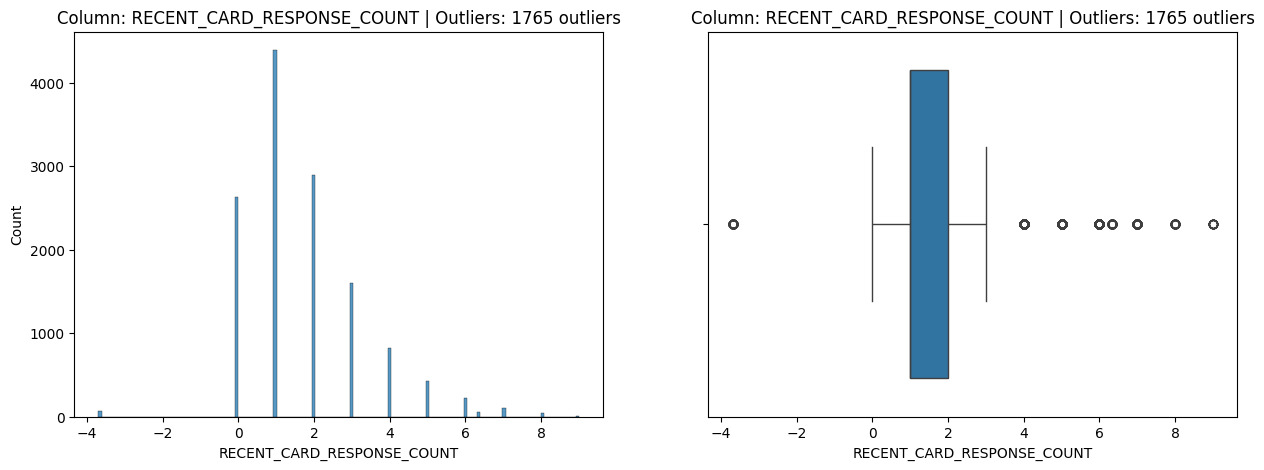

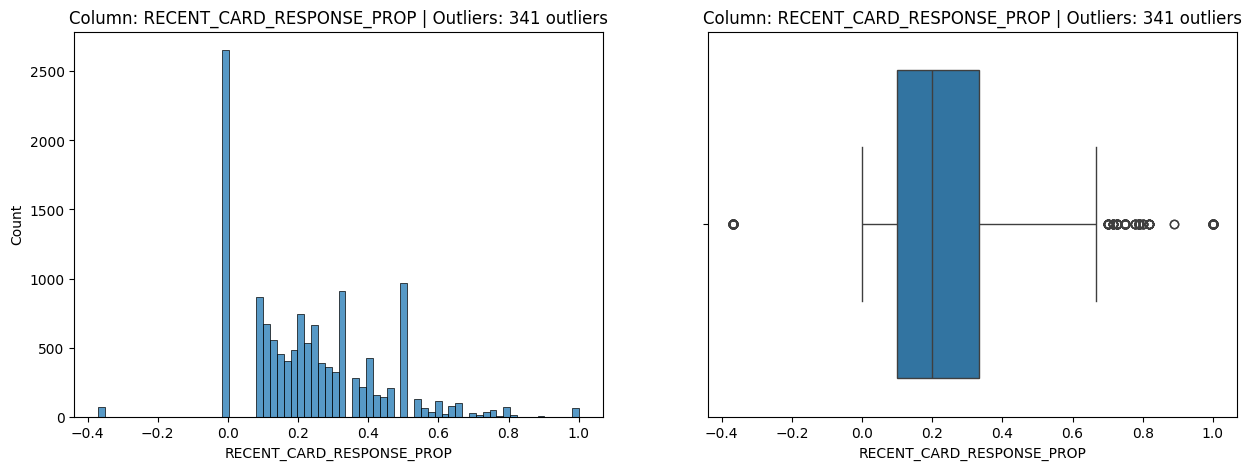

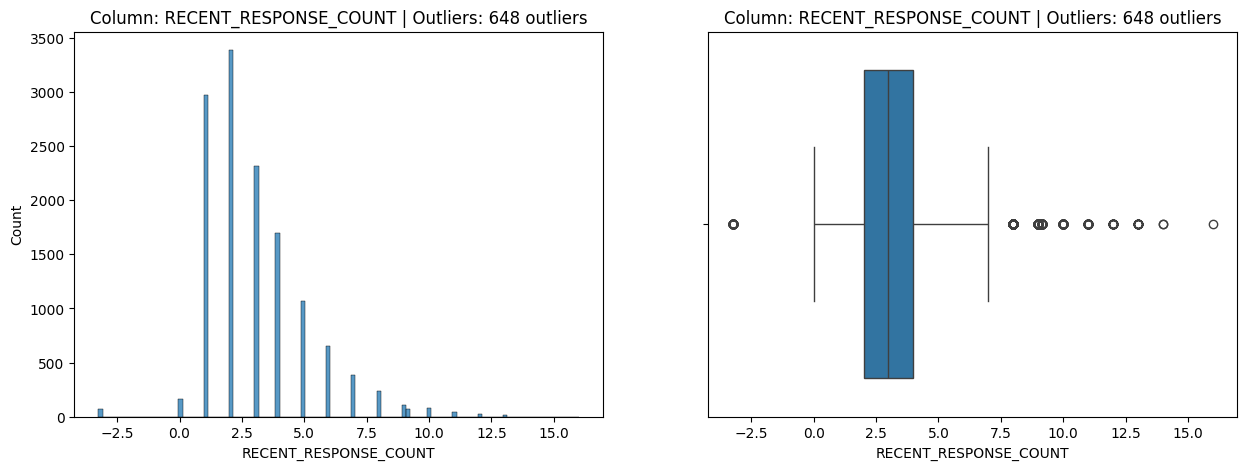

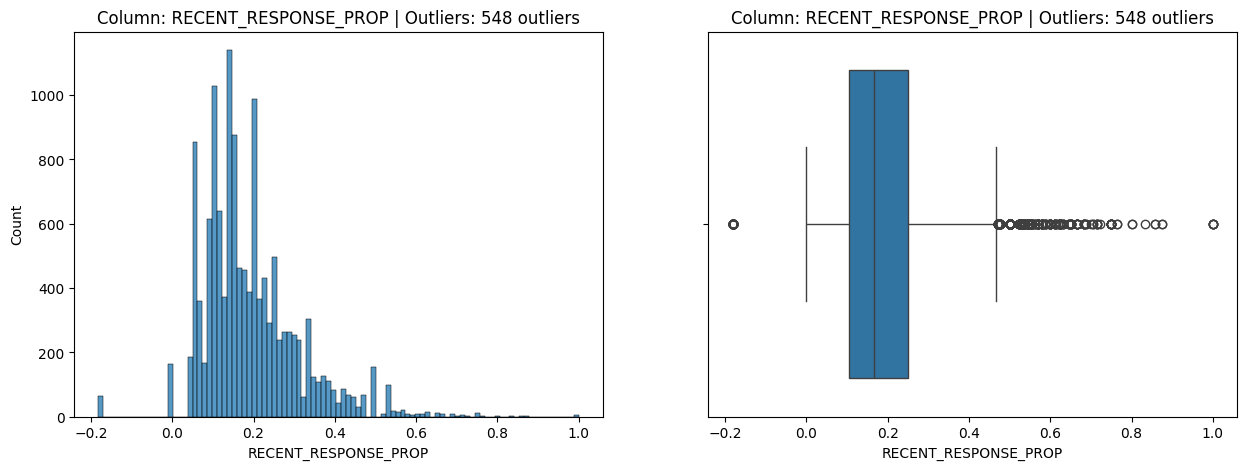

In [32]:
distribution_plot_grid(data, num_cols)

In [34]:
num_cols

Index(['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT',
       'FREQUENCY_STATUS_97NK', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM',
       'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT',
       'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_PROM', 'MEDIAN_HOME_VALUE',
       'MEDIAN_HOUSEHOLD_INCOME', 'MONTHS_SINCE_FIRST_GIFT',
       'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP',
       'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3',
       'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME',
       'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT',
       'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP',
       'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP'],
      dtype='str')

In [ ]:
sns.pairplot(data=data[list(num_cols) + ['TARGET_B']],  hue='TARGET_B')

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001D24AEA3380> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

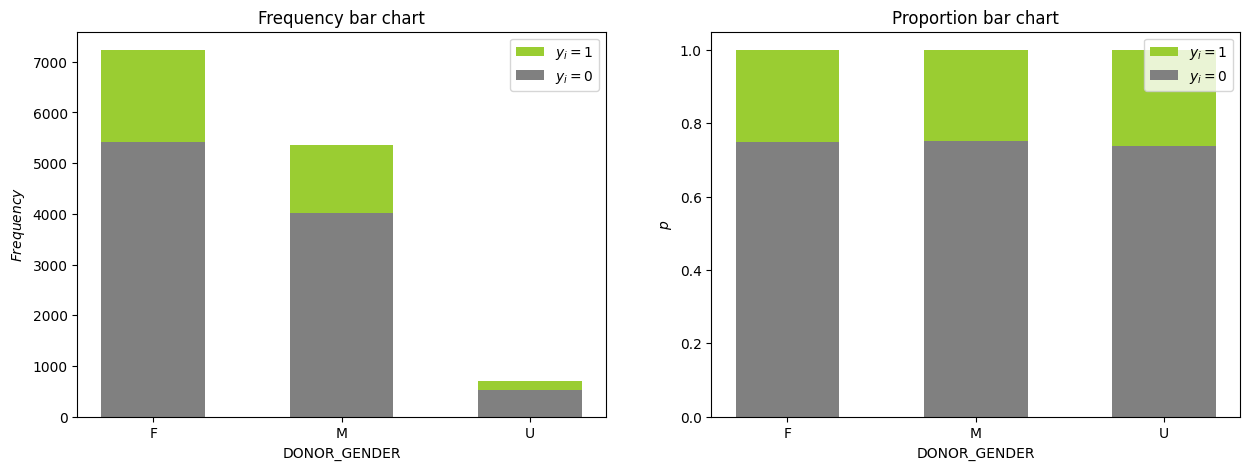

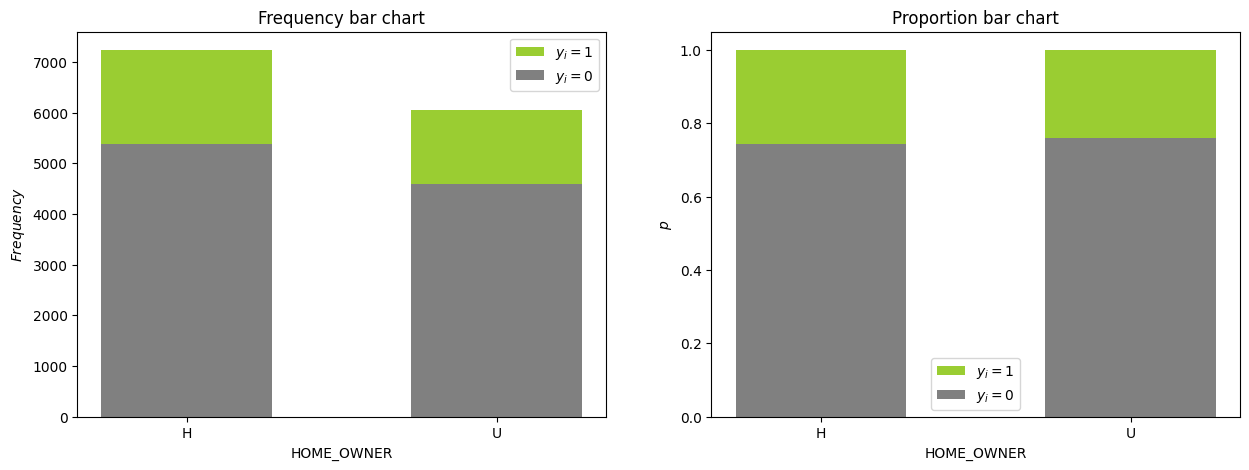

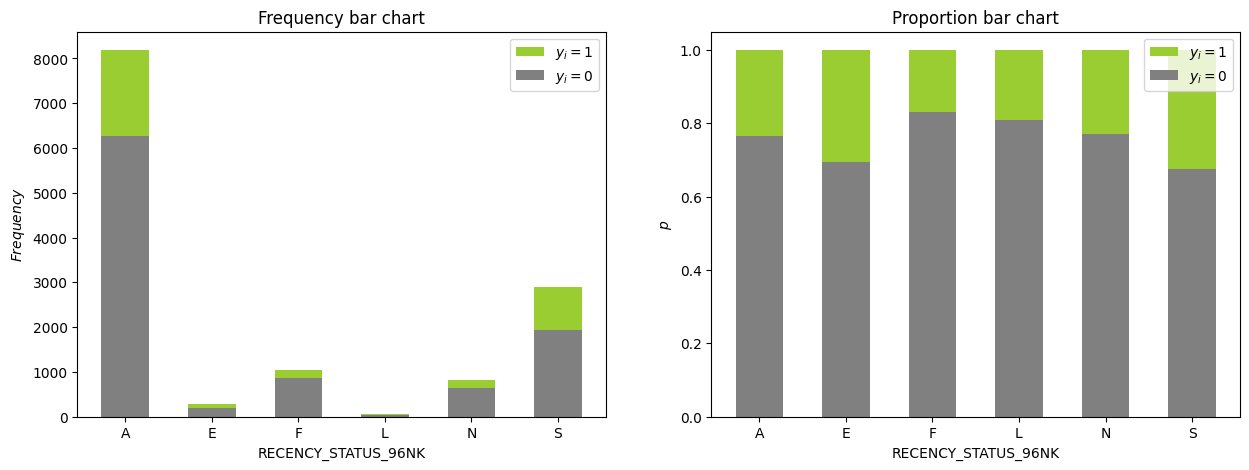

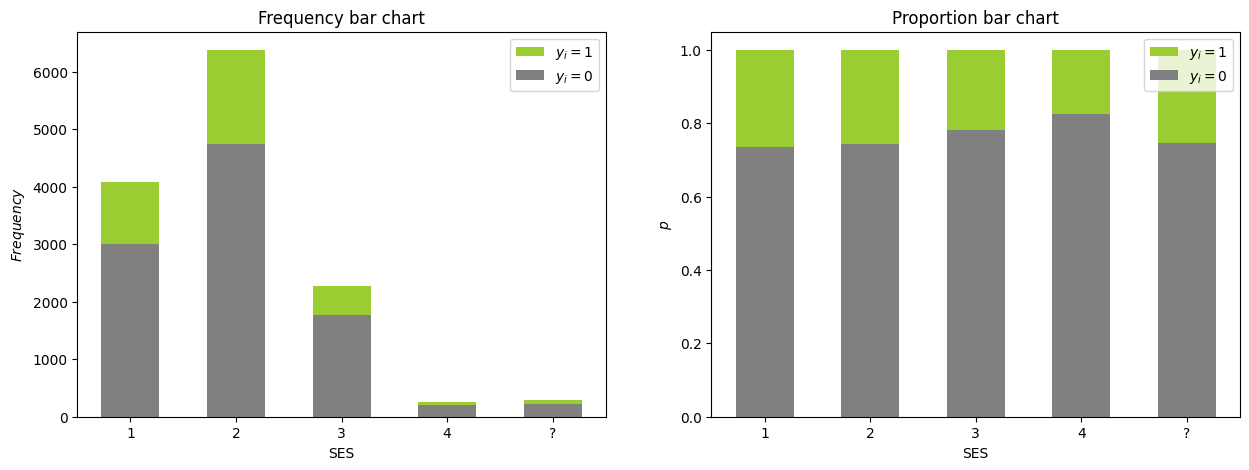

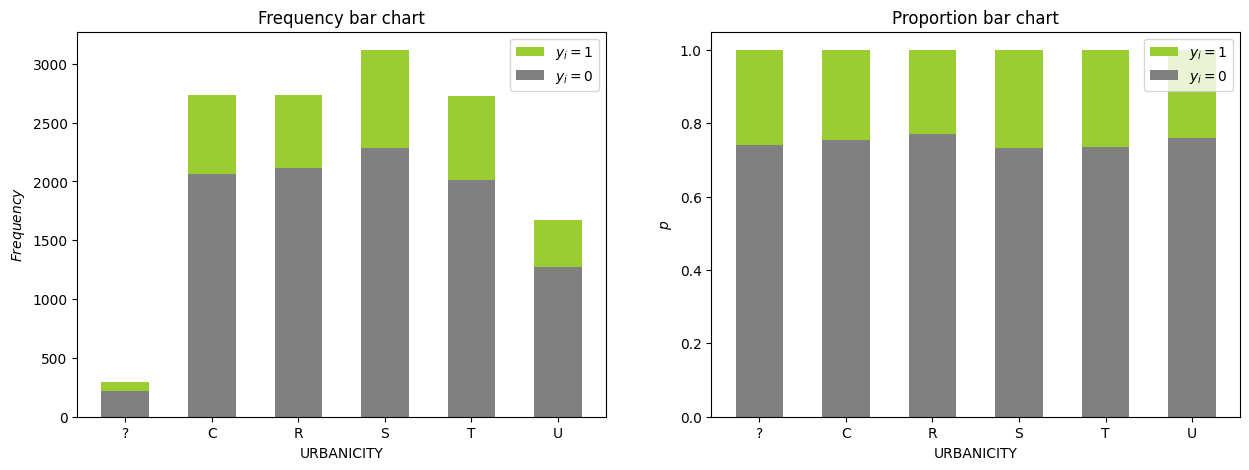

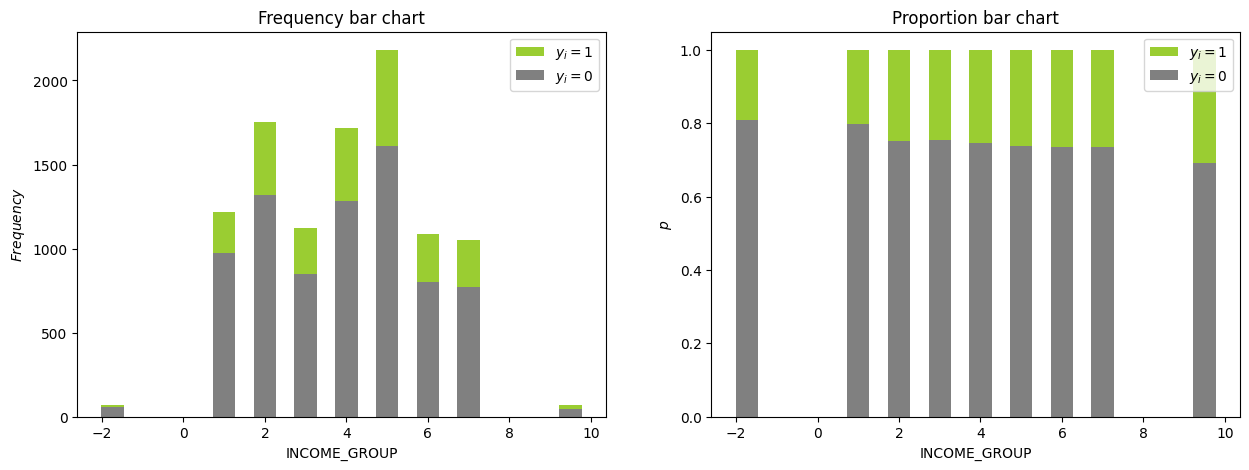

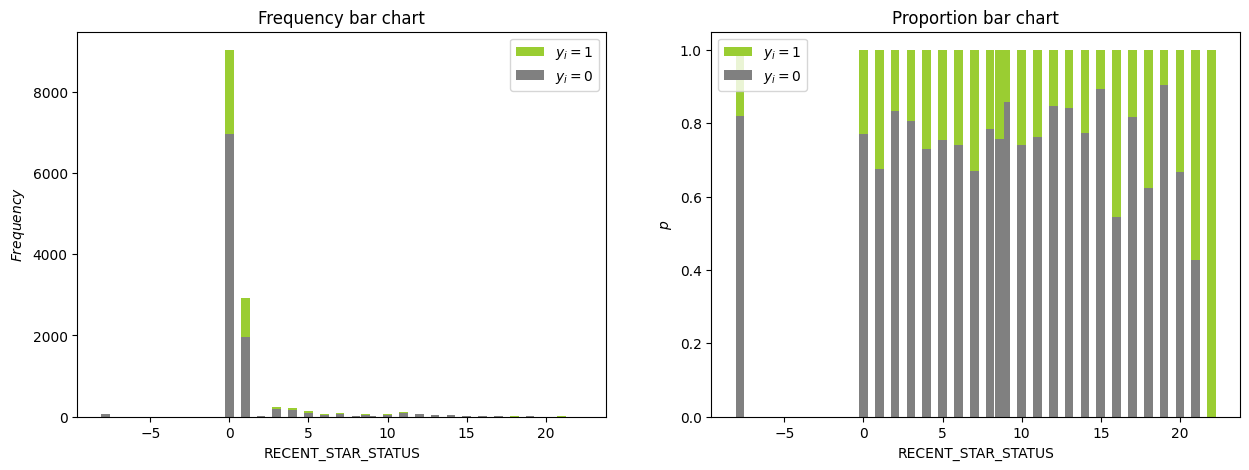

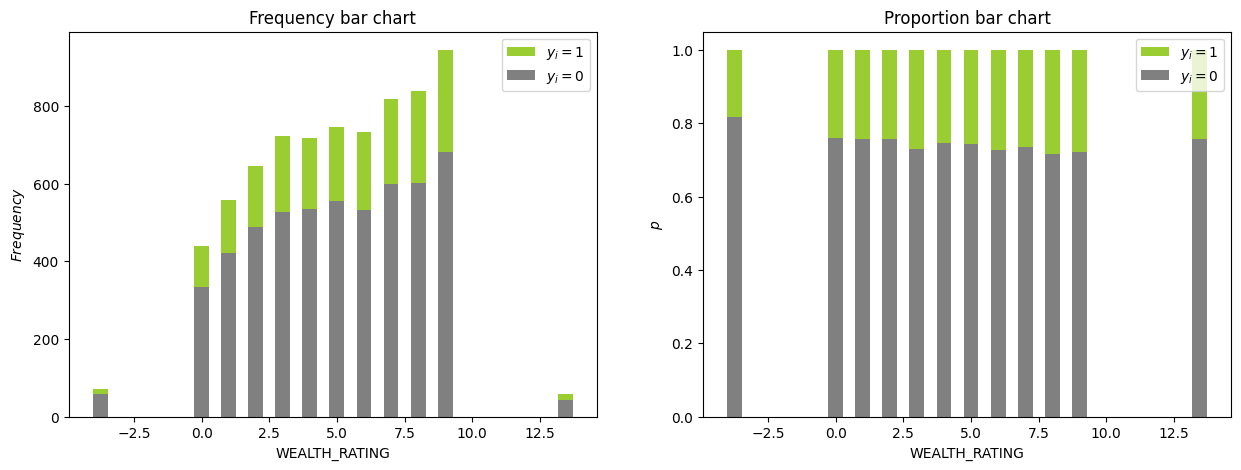

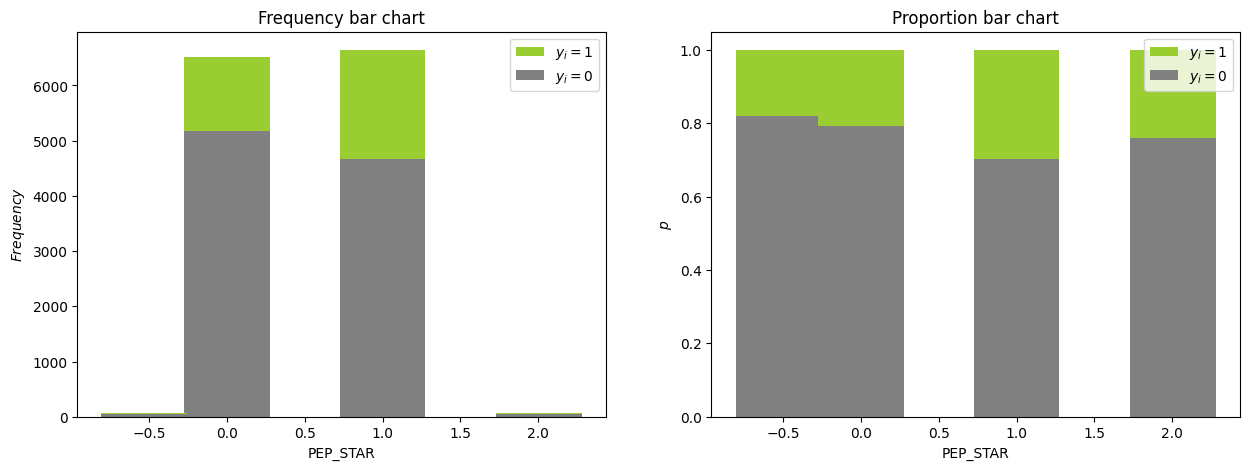

In [64]:
bar_charts_categorical(data, cat_cols, 'TARGET_B')

# Other/Extra

## Feature Selection?

In [65]:
data_no_nan = data.dropna()

In [66]:
chi2_TestIndependence(data, 'TARGET_B', cat_cols)

,Column,chi2 Keep?
0,DONOR_GENDER,0
1,HOME_OWNER,1
2,RECENCY_STATUS_96NK,1
3,SES,1
4,URBANICITY,1
5,INCOME_GROUP,1
6,RECENT_STAR_STATUS,1
7,WEALTH_RATING,0
8,PEP_STAR,1


In [67]:
chi2_TestIndependence(data_no_nan, 'TARGET_B', cat_cols)

,Column,chi2 Keep?
0,DONOR_GENDER,0
1,HOME_OWNER,0
2,RECENCY_STATUS_96NK,1
3,SES,1
4,URBANICITY,0
5,INCOME_GROUP,0
6,RECENT_STAR_STATUS,0
7,WEALTH_RATING,0
8,PEP_STAR,1


In [68]:
encoder = OrdinalEncoder()
encoded = encoder.fit_transform(data_no_nan[cat_cols])
encoded

array([[ 0.,  0.,  0., ...,  1.,  2.,  1.],
       [ 0.,  0.,  0., ...,  1.,  2.,  1.],
       [ 0.,  0.,  0., ...,  1.,  8.,  1.],
       ...,
       [ 1.,  1.,  5., ...,  2.,  7.,  2.],
       [ 1.,  0.,  0., ...,  1., 10.,  1.],
       [ 0.,  0.,  5., ...,  2.,  4.,  2.]], shape=(2345, 9))

In [69]:
anova = SelectKBest(f_classif, k='all')
X_anova = anova.fit_transform(encoded, data_no_nan['TARGET_B'])
selected_features = pd.Series(anova.get_support(), index = cat_cols)
selected_features

DONOR_GENDER           True
HOME_OWNER             True
RECENCY_STATUS_96NK    True
SES                    True
URBANICITY             True
INCOME_GROUP           True
RECENT_STAR_STATUS     True
WEALTH_RATING          True
PEP_STAR               True
dtype: bool

In [70]:
feature_scores = pd.Series(anova.pvalues_, index = cat_cols)
feature_scores

DONOR_GENDER          0.86
HOME_OWNER            0.23
RECENCY_STATUS_96NK   0.01
SES                   0.12
URBANICITY            0.42
INCOME_GROUP          0.05
RECENT_STAR_STATUS    0.68
WEALTH_RATING         0.26
PEP_STAR              0.00
dtype: float64

In [77]:
corr = data[list(num_cols) + ['TARGET_B']].corr('spearman')

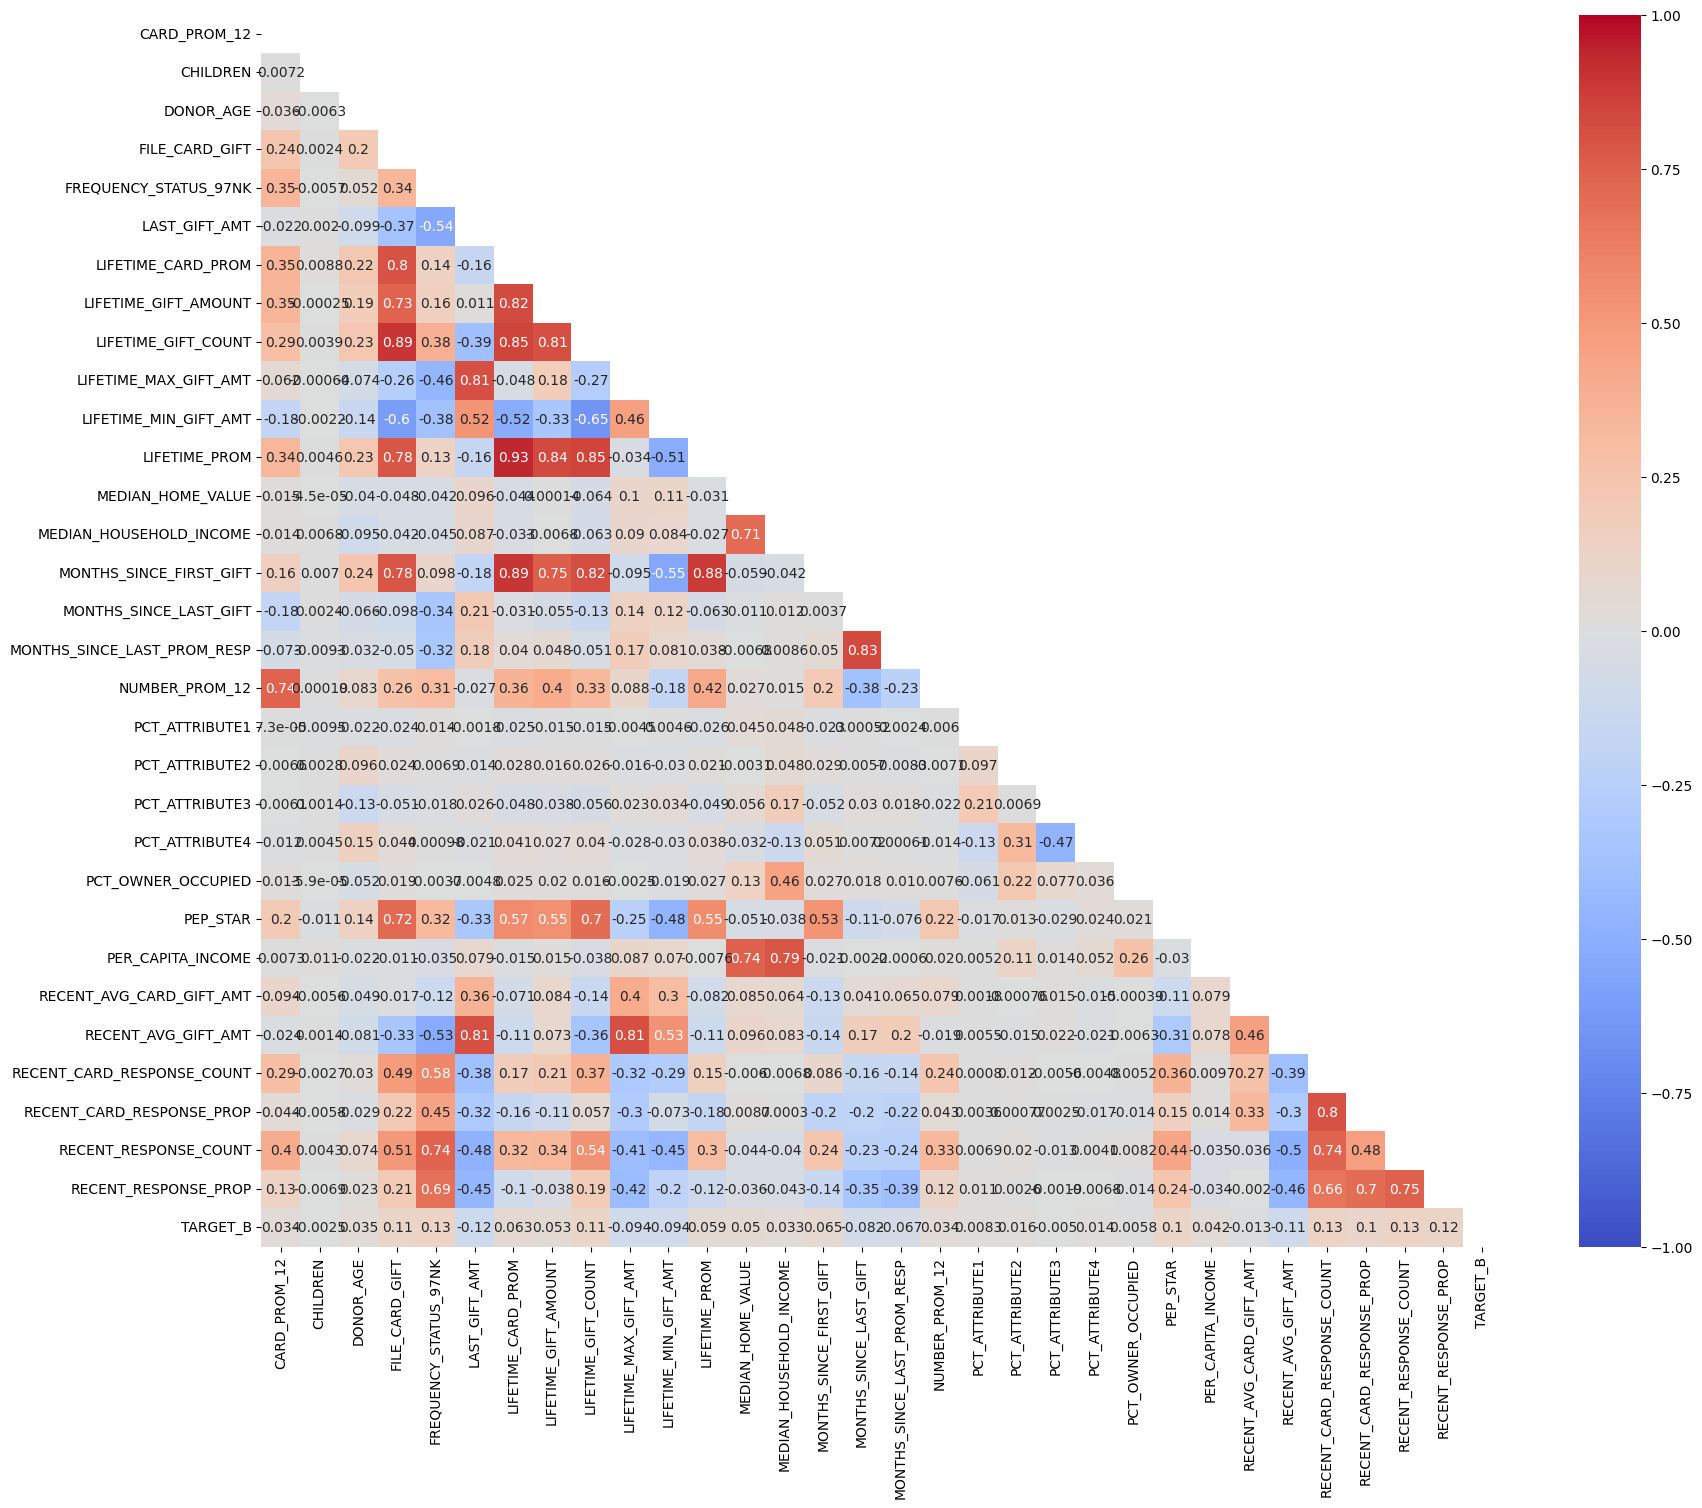

In [78]:
cor_heatmap(corr)